Импортируем библиотеки:

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import zipfile
import os

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [53]:
# Загрузка датасета
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Путь к датасету:", path)

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
Путь к датасету: /kaggle/input/nasa-cmaps


#Задача 1. Загрузка и исследование данных


---


- Загрузить все обучающие и тестовые датасеты
- Провести разведочный анализ данных (Exploratory Data Analysis, EDA)
- Зафиксировать размерность данных, наличие пропущенных значений и базовую
статистику
- Создать визуализации динамики показаний датчиков во времени

### Разведочный анализ данных (EDA)

In [54]:
# Проверка файлов
print("Файлы в датасете:")
for file in os.listdir(path):
    print(f" - {file}")

cmaps_path = os.path.join(path, "CMaps")
print("Путь к данным CMaps:", cmaps_path)

print("\nСодержимое CMaps:")
for item in os.listdir(cmaps_path):
    item_path = os.path.join(cmaps_path, item)
    print(f" - {item} ({'папка' if os.path.isdir(item_path) else 'файл'})")

Файлы в датасете:
 - CMaps
Путь к данным CMaps: /kaggle/input/nasa-cmaps/CMaps

Содержимое CMaps:
 - RUL_FD002.txt (файл)
 - test_FD003.txt (файл)
 - Damage Propagation Modeling.pdf (файл)
 - readme.txt (файл)
 - train_FD003.txt (файл)
 - test_FD004.txt (файл)
 - train_FD004.txt (файл)
 - x.txt (файл)
 - test_FD002.txt (файл)
 - train_FD001.txt (файл)
 - train_FD002.txt (файл)
 - RUL_FD001.txt (файл)
 - RUL_FD004.txt (файл)
 - RUL_FD003.txt (файл)
 - test_FD001.txt (файл)


In [55]:
def load_all_datasets(cmaps_path):
    datasets = {}
    for item in os.listdir(cmaps_path):
        item_path = os.path.join(cmaps_path, item)
        if os.path.isfile(item_path) and item.endswith('.txt') and ('train' in item or 'test' in item or 'RUL' in item):
            # Load files, assuming space-separated values and no header
            df = pd.read_csv(item_path, sep='\s+', header=None)
            datasets[item] = df
    return datasets

datasets = load_all_datasets(cmaps_path)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-192257849.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(item_path, sep='\s+', header=None)


In [56]:
# Анализ качества данных и сбор базовой статистики
for name, df in datasets.items():
    if name.startswith('train_FD'):
        print(f"\n--- Данные для {name} ---")
        print(f"Размерность данных: {df.shape}")
        print("\nТипы данных:\n", df.dtypes)
        print("\nКоличество пропущенных значений:\n", df.isnull().sum().sum())
        print("\nКоличество дубликатов:\n", df.duplicated().sum())
        print("\nПервые строки:\n", df.head(3))
        print("\nПоследние строки:\n", df.tail(3))
        print("\nБазовая статистика (первые 5 столбцов):")
        print(df.iloc[:, :5].describe())
        print("\nБазовая статистика (последние 5 столбцов):")
        print(df.iloc[:, -5:].describe())


--- Данные для train_FD003.txt ---
Размерность данных: (24720, 26)

Типы данных:
 0       int64
1       int64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21      int64
22      int64
23    float64
24    float64
25    float64
dtype: object

Количество пропущенных значений:
 0

Количество дубликатов:
 0

Первые строки:
    0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0005  0.0004  100.0  518.67  642.36  1583.23  1396.84  14.62   
1   1   2  0.0008 -0.0003  100.0  518.67  642.50  1584.69  1396.89  14.62   
2   1   3 -0.0014 -0.0002  100.0  518.67  642.18  1582.35  1405.61  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  522.31  2388.01  8145.32  8.4246  0.03  391  2388  100.0  39.11   

In [57]:
for name, df in datasets.items():
    if name.startswith('test_FD'):
        print(f"\n--- Данные для {name} ---")
        print(f"Размерность данных: {df.shape}")
        print("\nТипы данных:\n", df.dtypes)
        print("\nКоличество пропущенных значений:\n", df.isnull().sum().sum())
        print("\nКоличество дубликатов:\n", df.duplicated().sum())
        print("\nПервые строки:\n", df.head(3))
        print("\nПоследние строки:\n", df.tail(3))
        print("\nБазовая статистика (первые 5 столбцов):")
        print(df.iloc[:, :5].describe())
        print("\nБазовая статистика (последние 5 столбцов):")
        print(df.iloc[:, -5:].describe())


--- Данные для test_FD003.txt ---
Размерность данных: (16596, 26)

Типы данных:
 0       int64
1       int64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21      int64
22      int64
23    float64
24    float64
25    float64
dtype: object

Количество пропущенных значений:
 0

Количество дубликатов:
 0

Первые строки:
    0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0017 -0.0004  100.0  518.67  641.94  1581.93  1396.93  14.62   
1   1   2  0.0006 -0.0002  100.0  518.67  642.02  1584.86  1398.90  14.62   
2   1   3  0.0014 -0.0003  100.0  518.67  641.68  1581.78  1391.92  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.89  2387.94  8133.48  8.3760  0.03  391  2388  100.0  39.07   


In [60]:
# Визулизация показаний датчиков в зависмотси от времени

'''
Согласно документации:
The columns correspond to:
1)	unit number
2)	time, in cycles
3)	operational setting 1
4)	operational setting 2
5)	operational setting 3
6)	sensor measurement  1
7)	sensor measurement  2
...
26)	sensor measurement  21
'''

# Создаем список наименований колонок
column_names = ['unit number', 'time, in cycles', 'operational setting 1',
                'operational setting 2', 'operational setting 3'] + \
               [f'sensor measurement {i}' for i in range(1, 22)]

# Для тренировочных файлов назовем колонки
train_files_names = [f for f in datasets.keys() if 'train' in f.lower()]

for file_name in train_files_names:
    df = datasets[file_name]
    if len(df.columns) == len(column_names):
        df.columns = column_names
        datasets[file_name] = df

test_files_names = [f for f in datasets.keys() if 'test' in f.lower()]

for file_name in test_files_names:
    df = datasets[file_name]
    if len(df.columns) == len(column_names):
        df.columns = column_names
        datasets[file_name] = df

# Для RUL обозначим колонку
rul_files = [f for f in datasets.keys() if 'rul' in f.lower()]

for file_name in rul_files:
    df = datasets[file_name]
    df.columns = ['RUL']
    datasets[file_name] = df

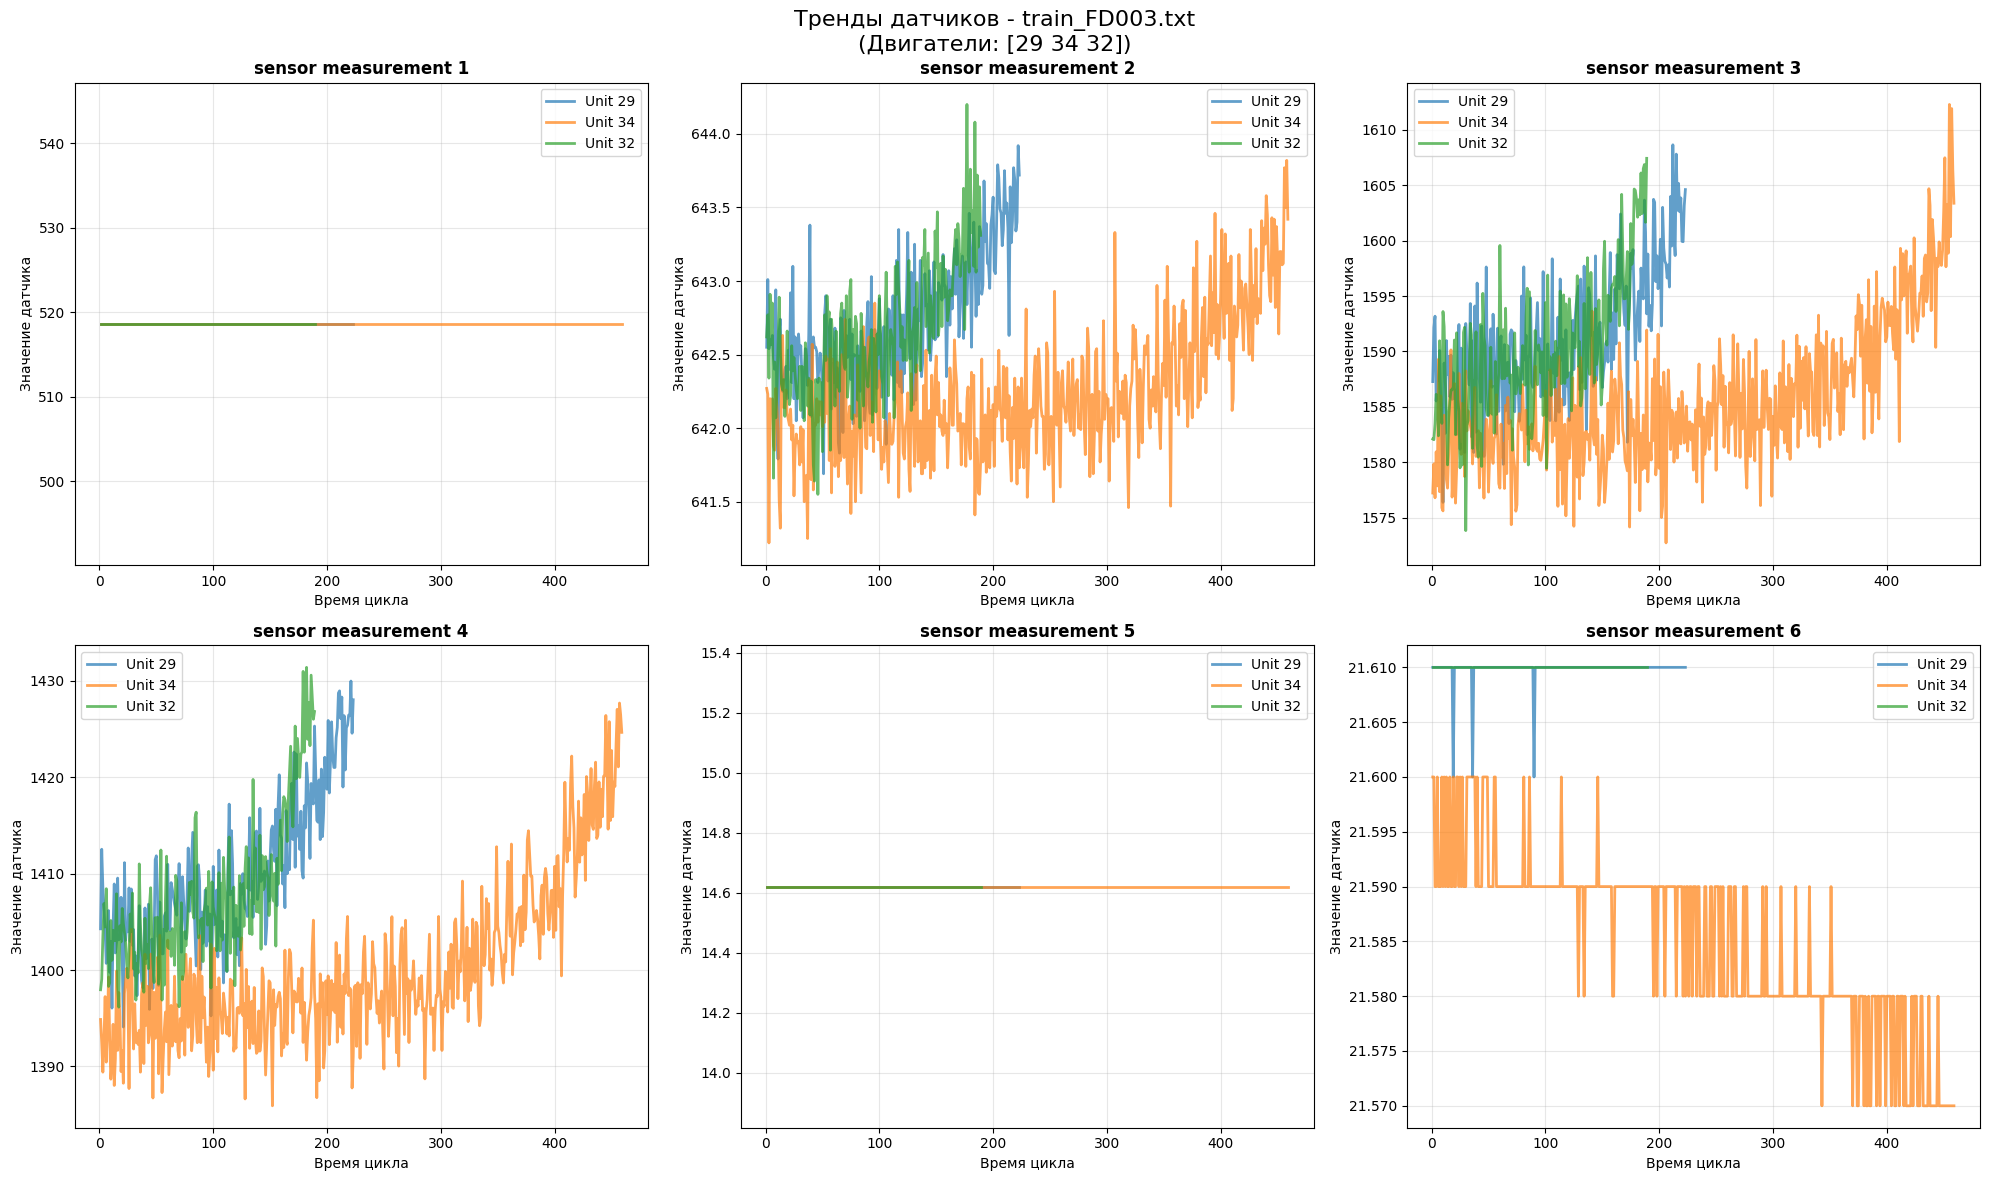

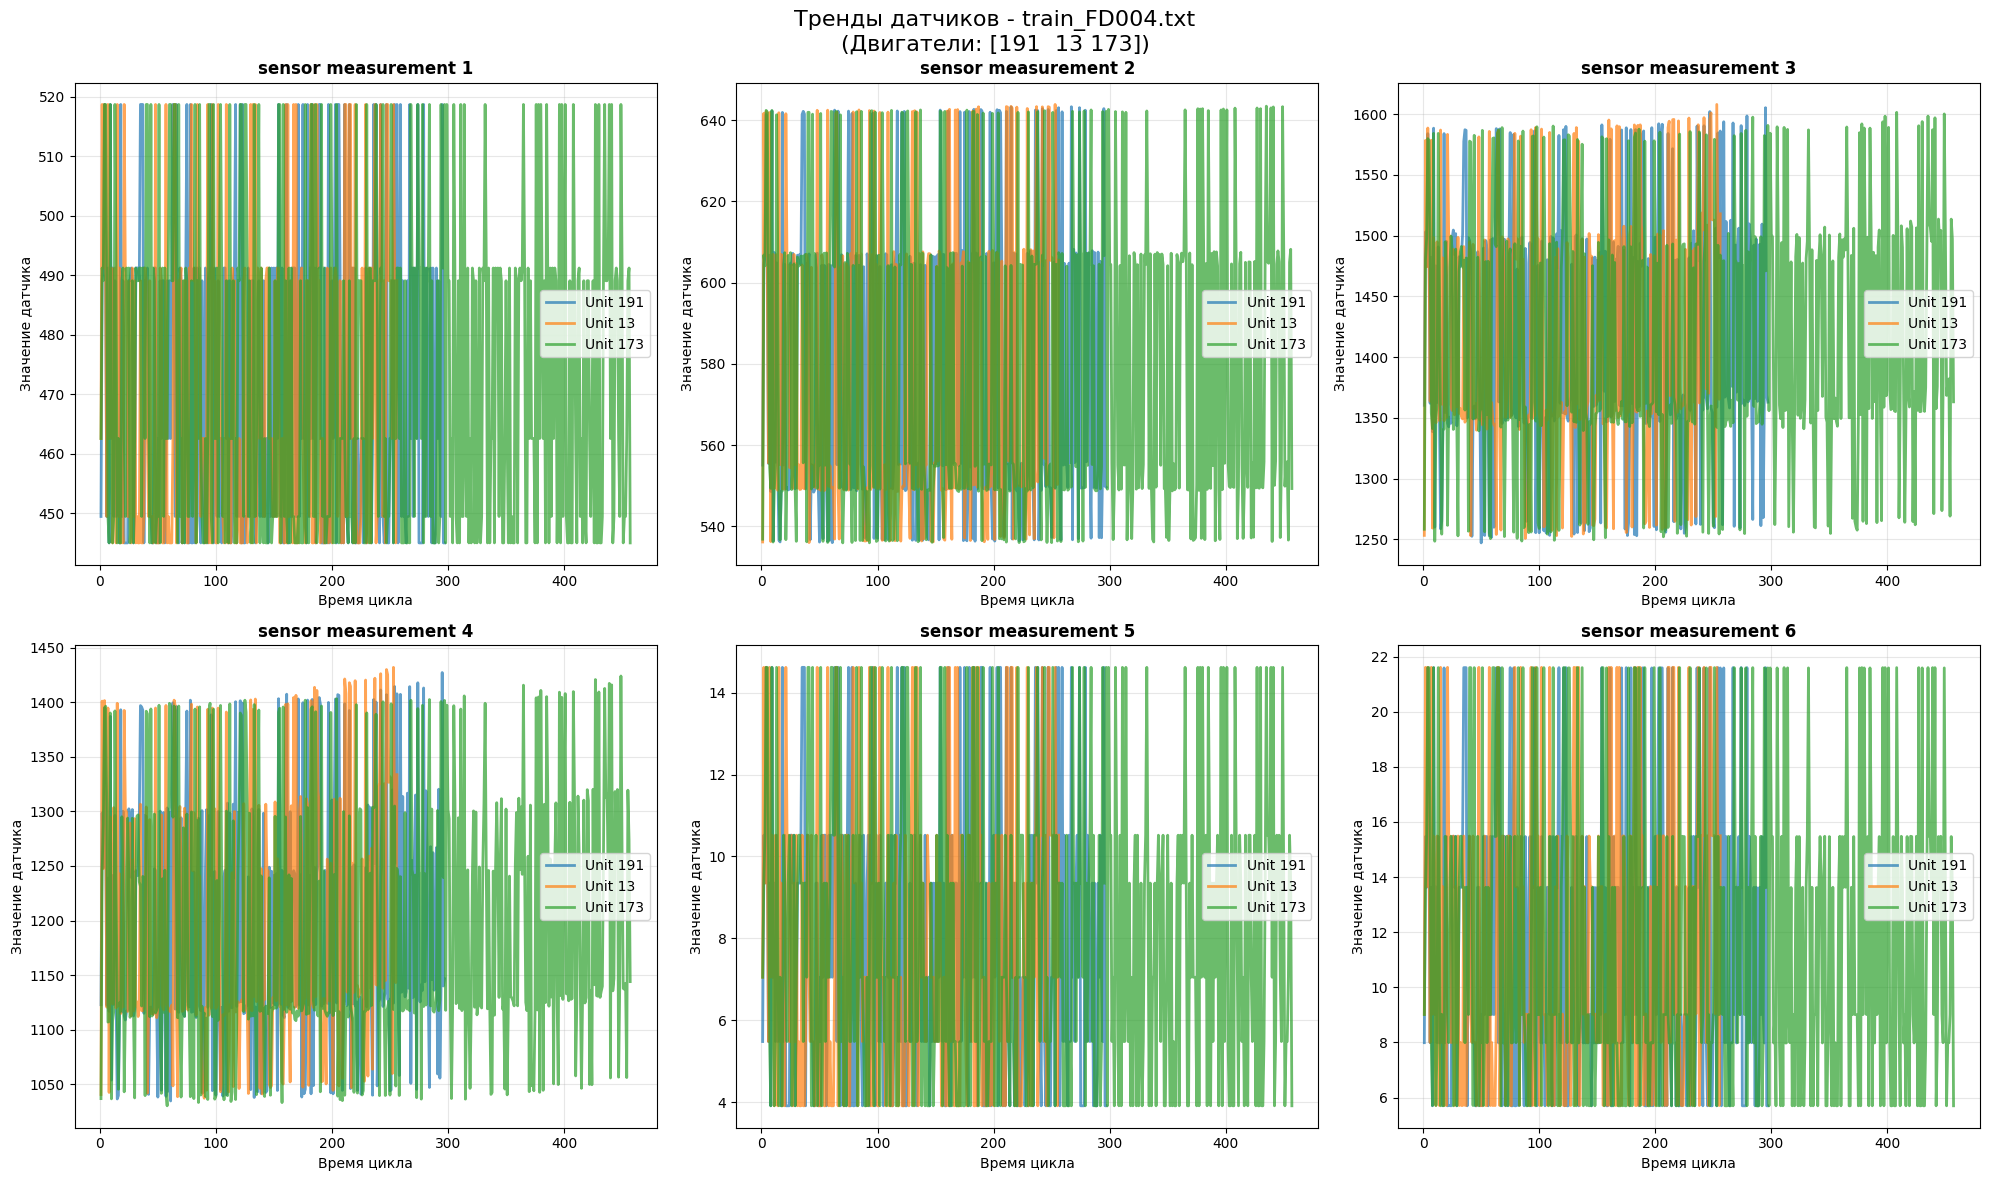

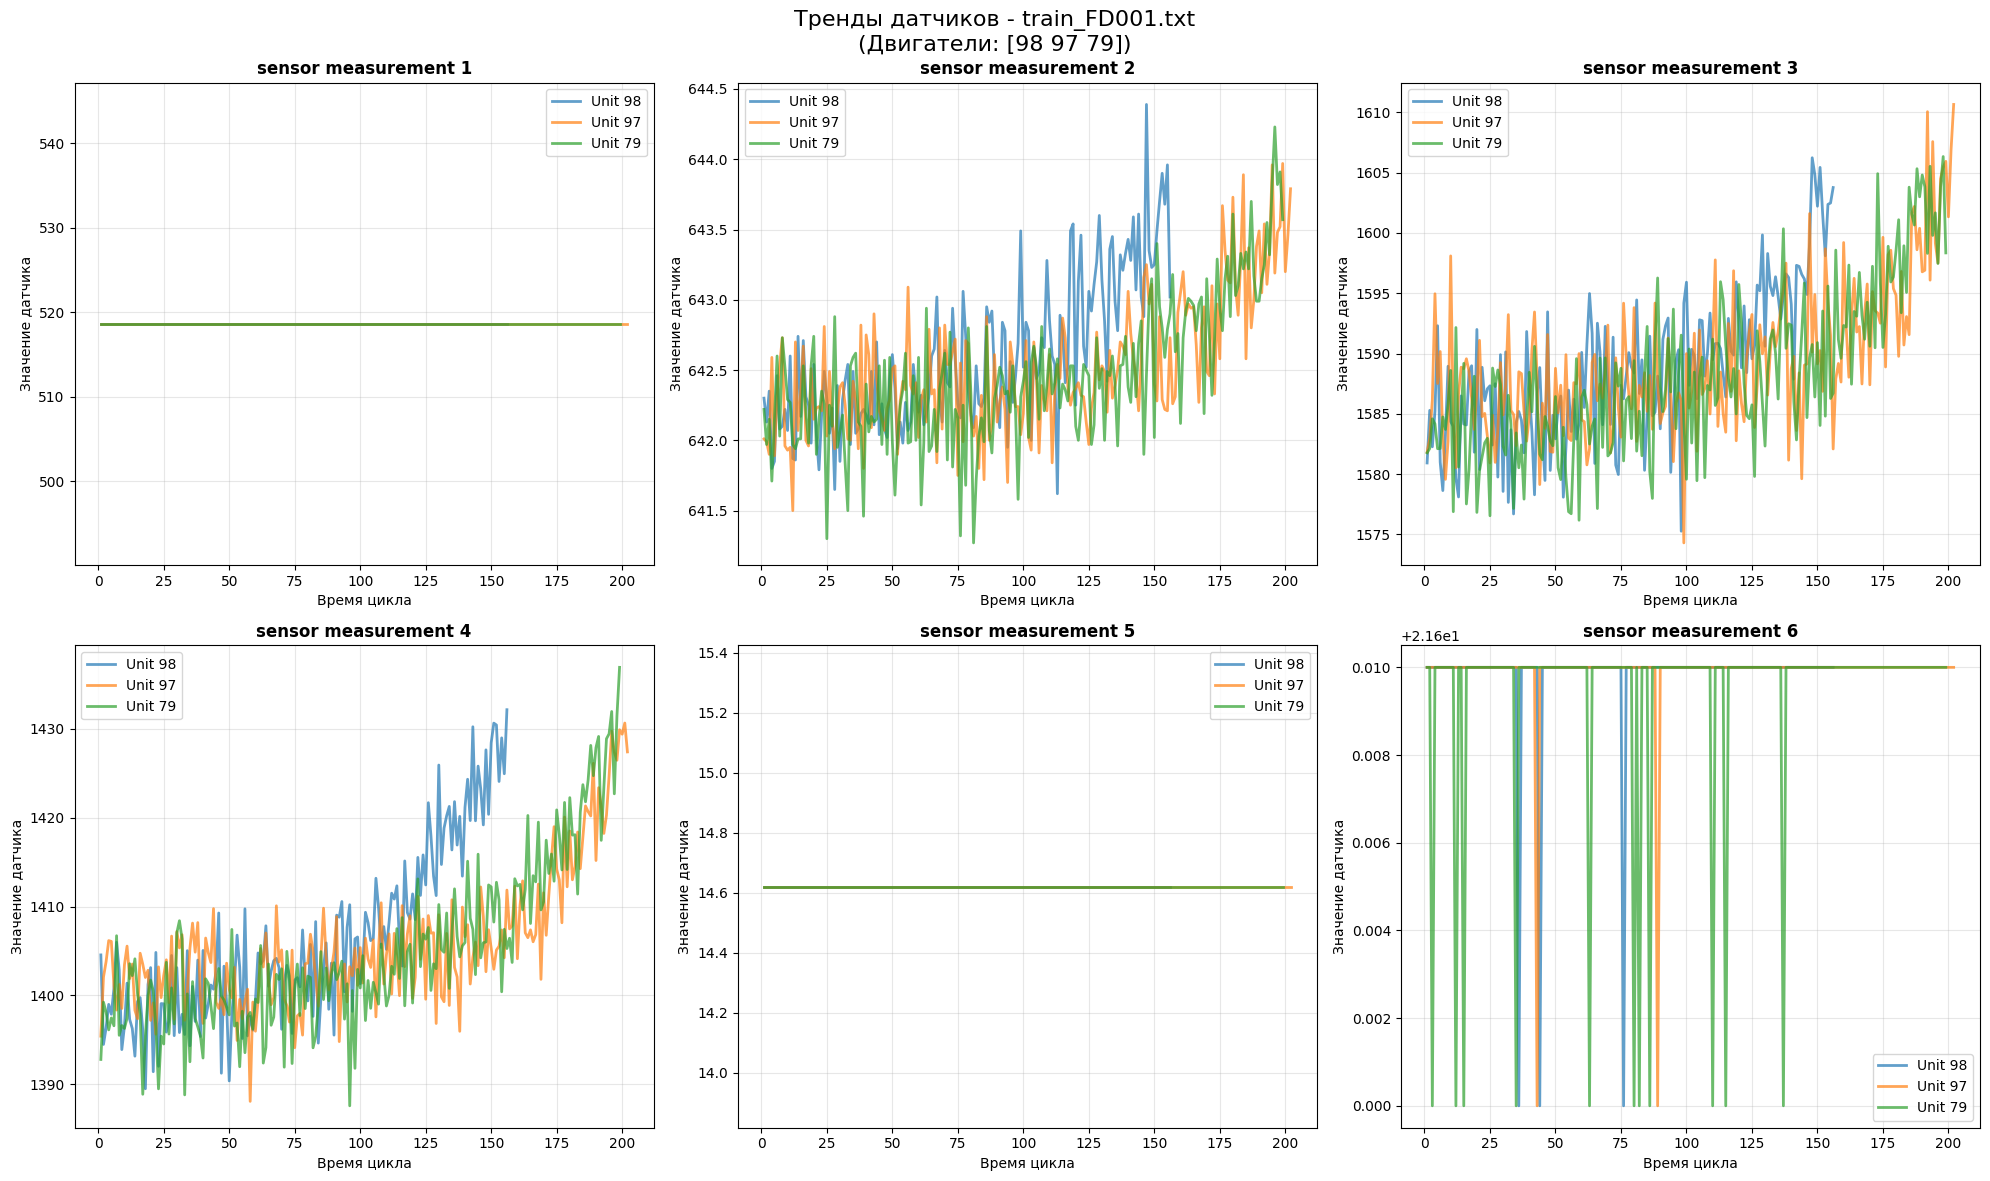

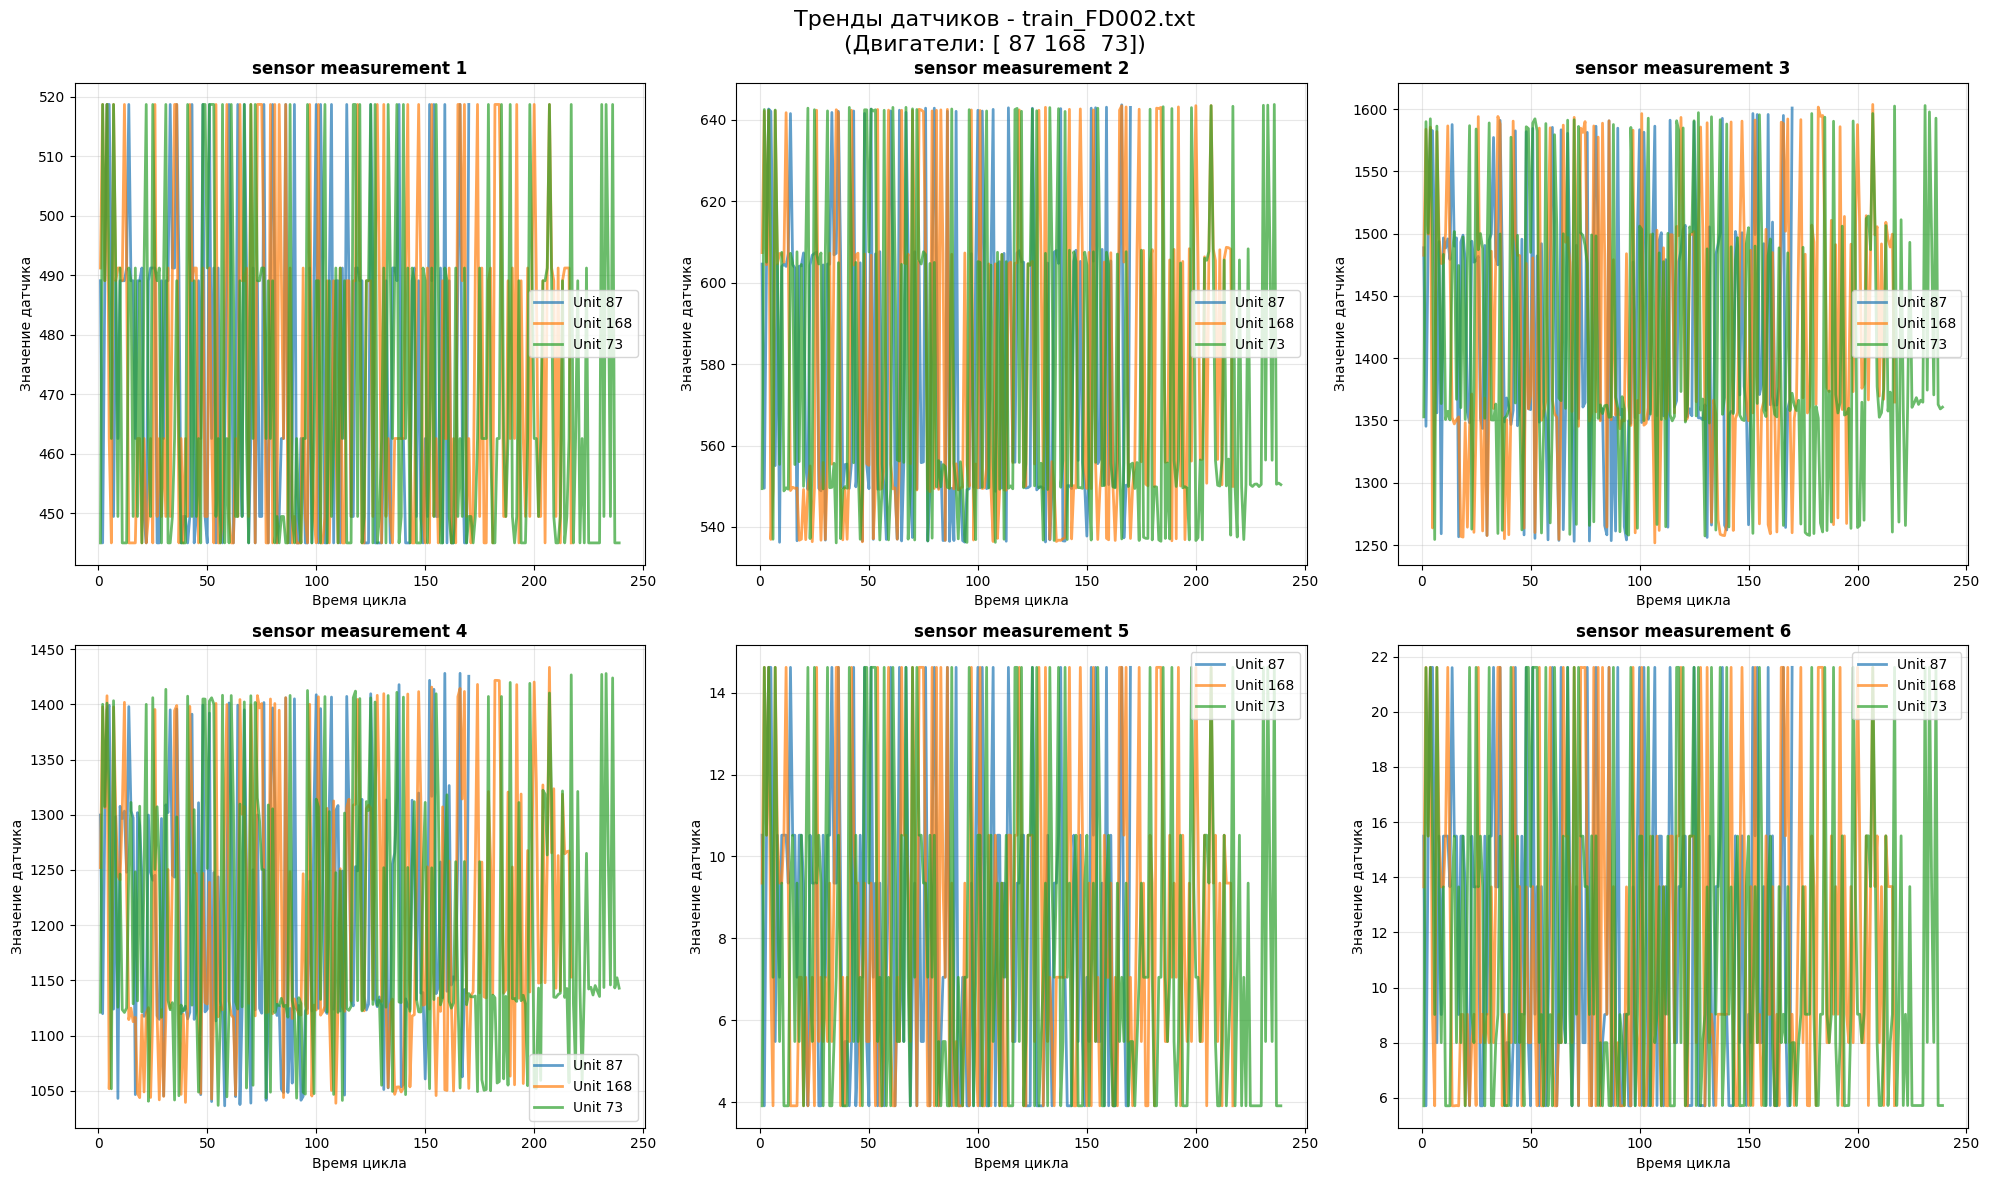

In [59]:
def plot_sensor_trends_multiple_units(df, dataset_name, n_units=3, sensors_to_plot=6):
    """
    Визуализация трендов датчиков для нескольких двигателей
    """
    # Выбираем случайные двигатели
    unit_numbers = np.random.choice(df['unit number'].unique(), n_units, replace=False)


    # Выбираем ключевые сенсоры для визуализации (первые 6)
    sensor_cols = [col for col in df.columns if 'sensor' in col][:sensors_to_plot]

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Тренды датчиков - {dataset_name}\n(Двигатели: {unit_numbers})', fontsize=16)

    axes = axes.flatten()

    for i, sensor in enumerate(sensor_cols):
        if i < len(axes):
            ax = axes[i]
            for unit_number in unit_numbers:
                unit_data = df[df['unit number'] == unit_number]
                ax.plot(unit_data['time, in cycles'], unit_data[sensor],
                       label=f'Unit {unit_number}', alpha=0.7, linewidth=2)

            ax.set_title(f'{sensor}', fontweight='bold')
            ax.set_xlabel('Время цикла')
            ax.set_ylabel('Значение датчика')
            ax.grid(True, alpha=0.3)
            ax.legend()

    # Убираем лишние subplots
    for i in range(len(sensor_cols), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Применяем для каждого тренировочного датасета
for name, df in datasets.items():
    if 'train' in name.lower() and 'unit number' in df.columns:
        plot_sensor_trends_multiple_units(df, name)

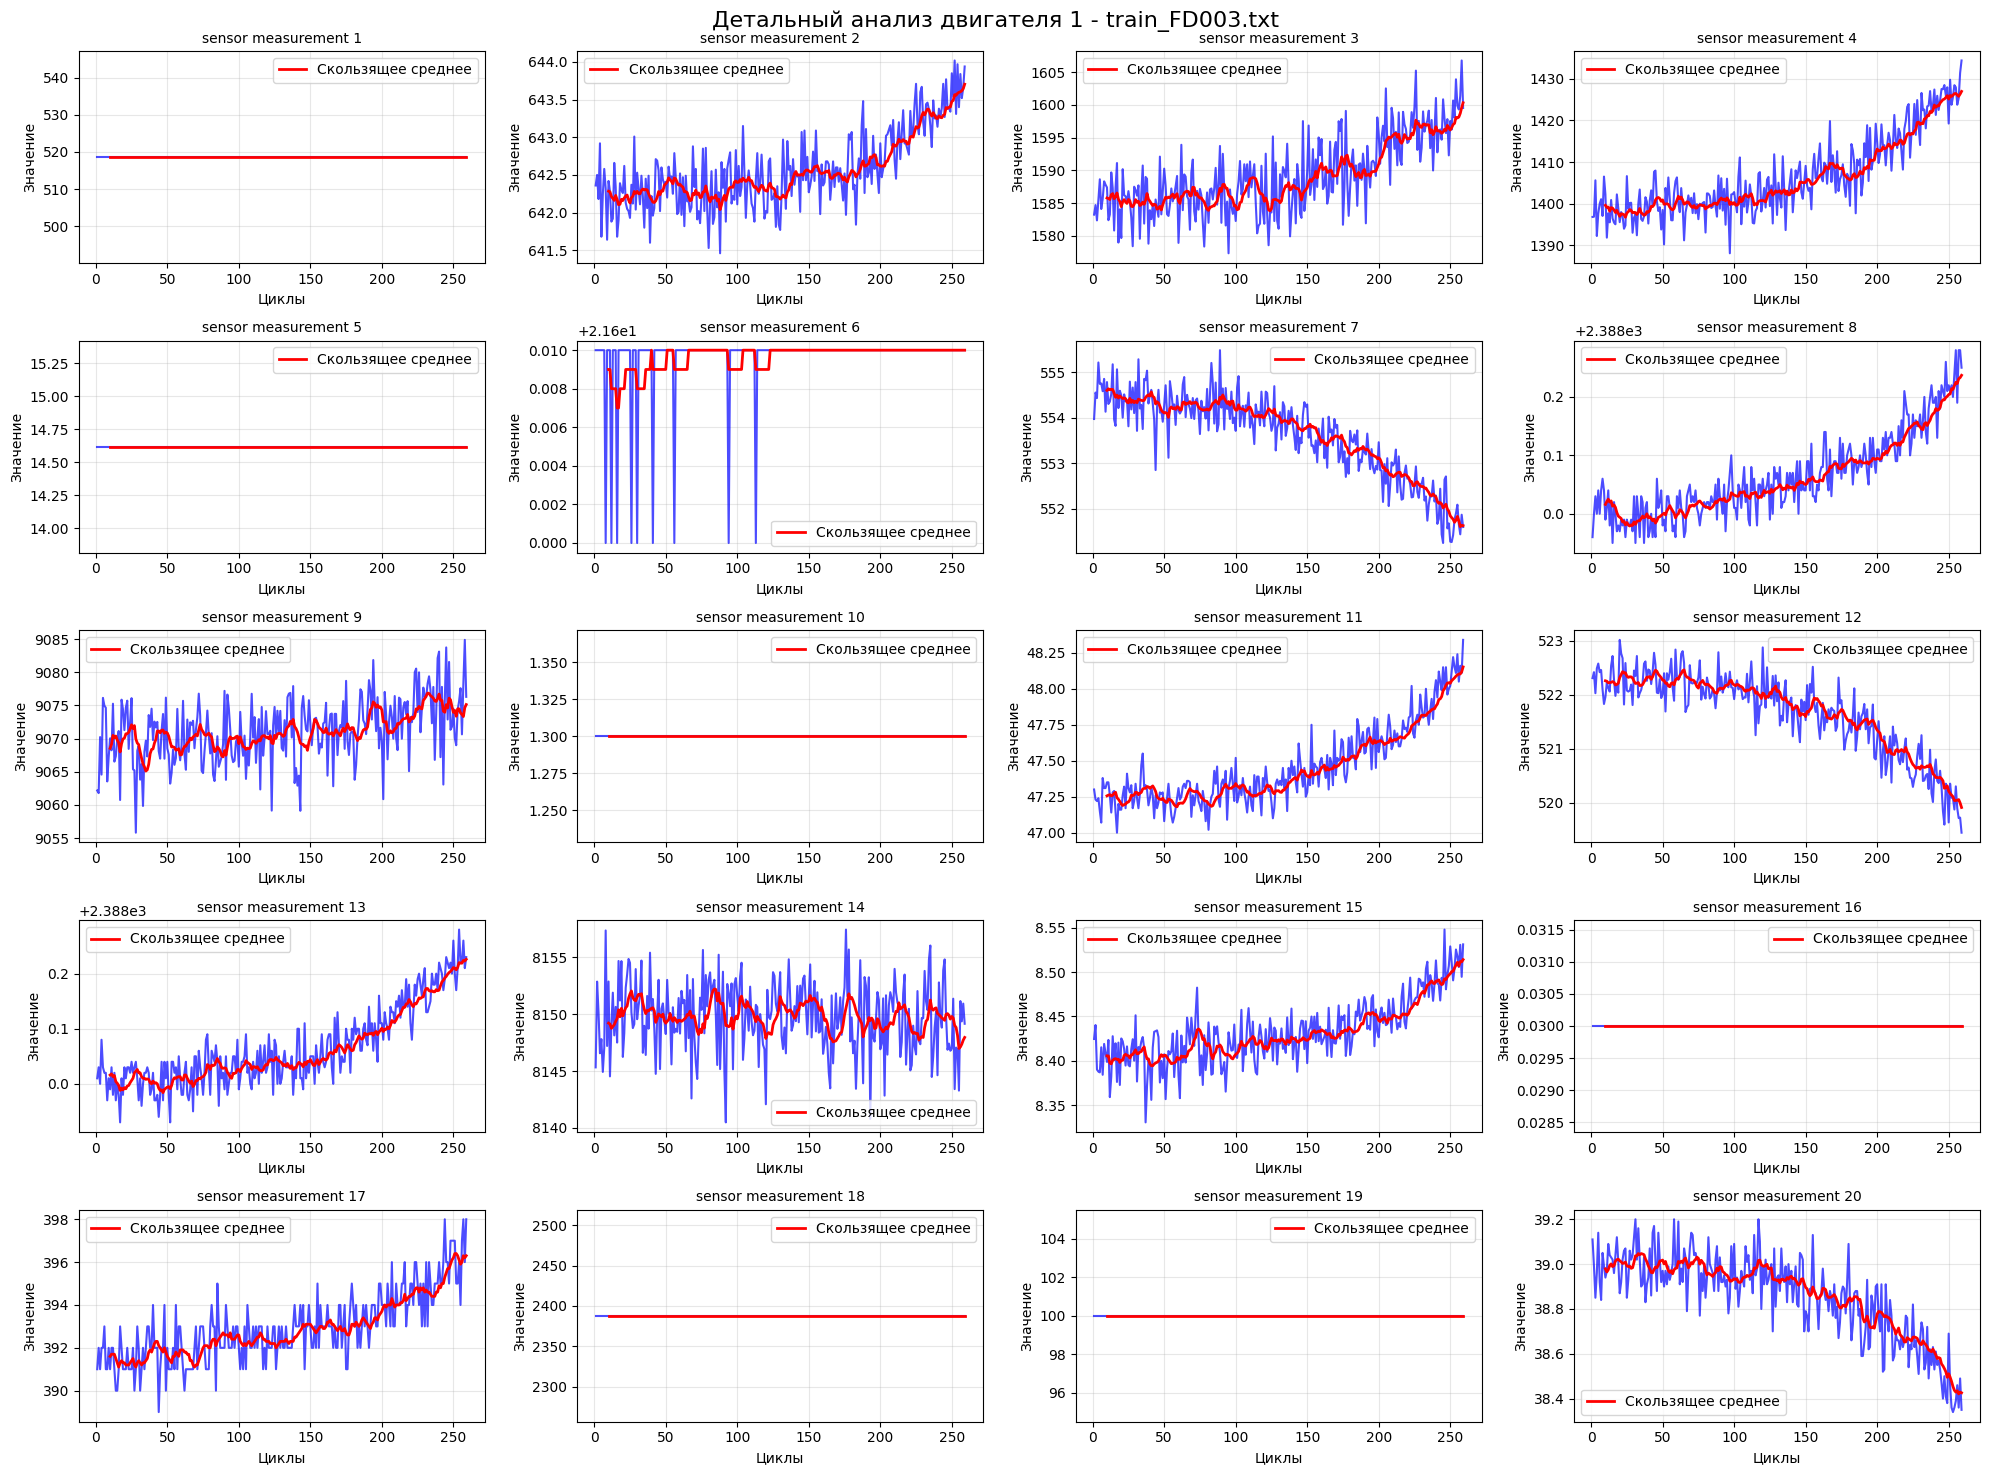

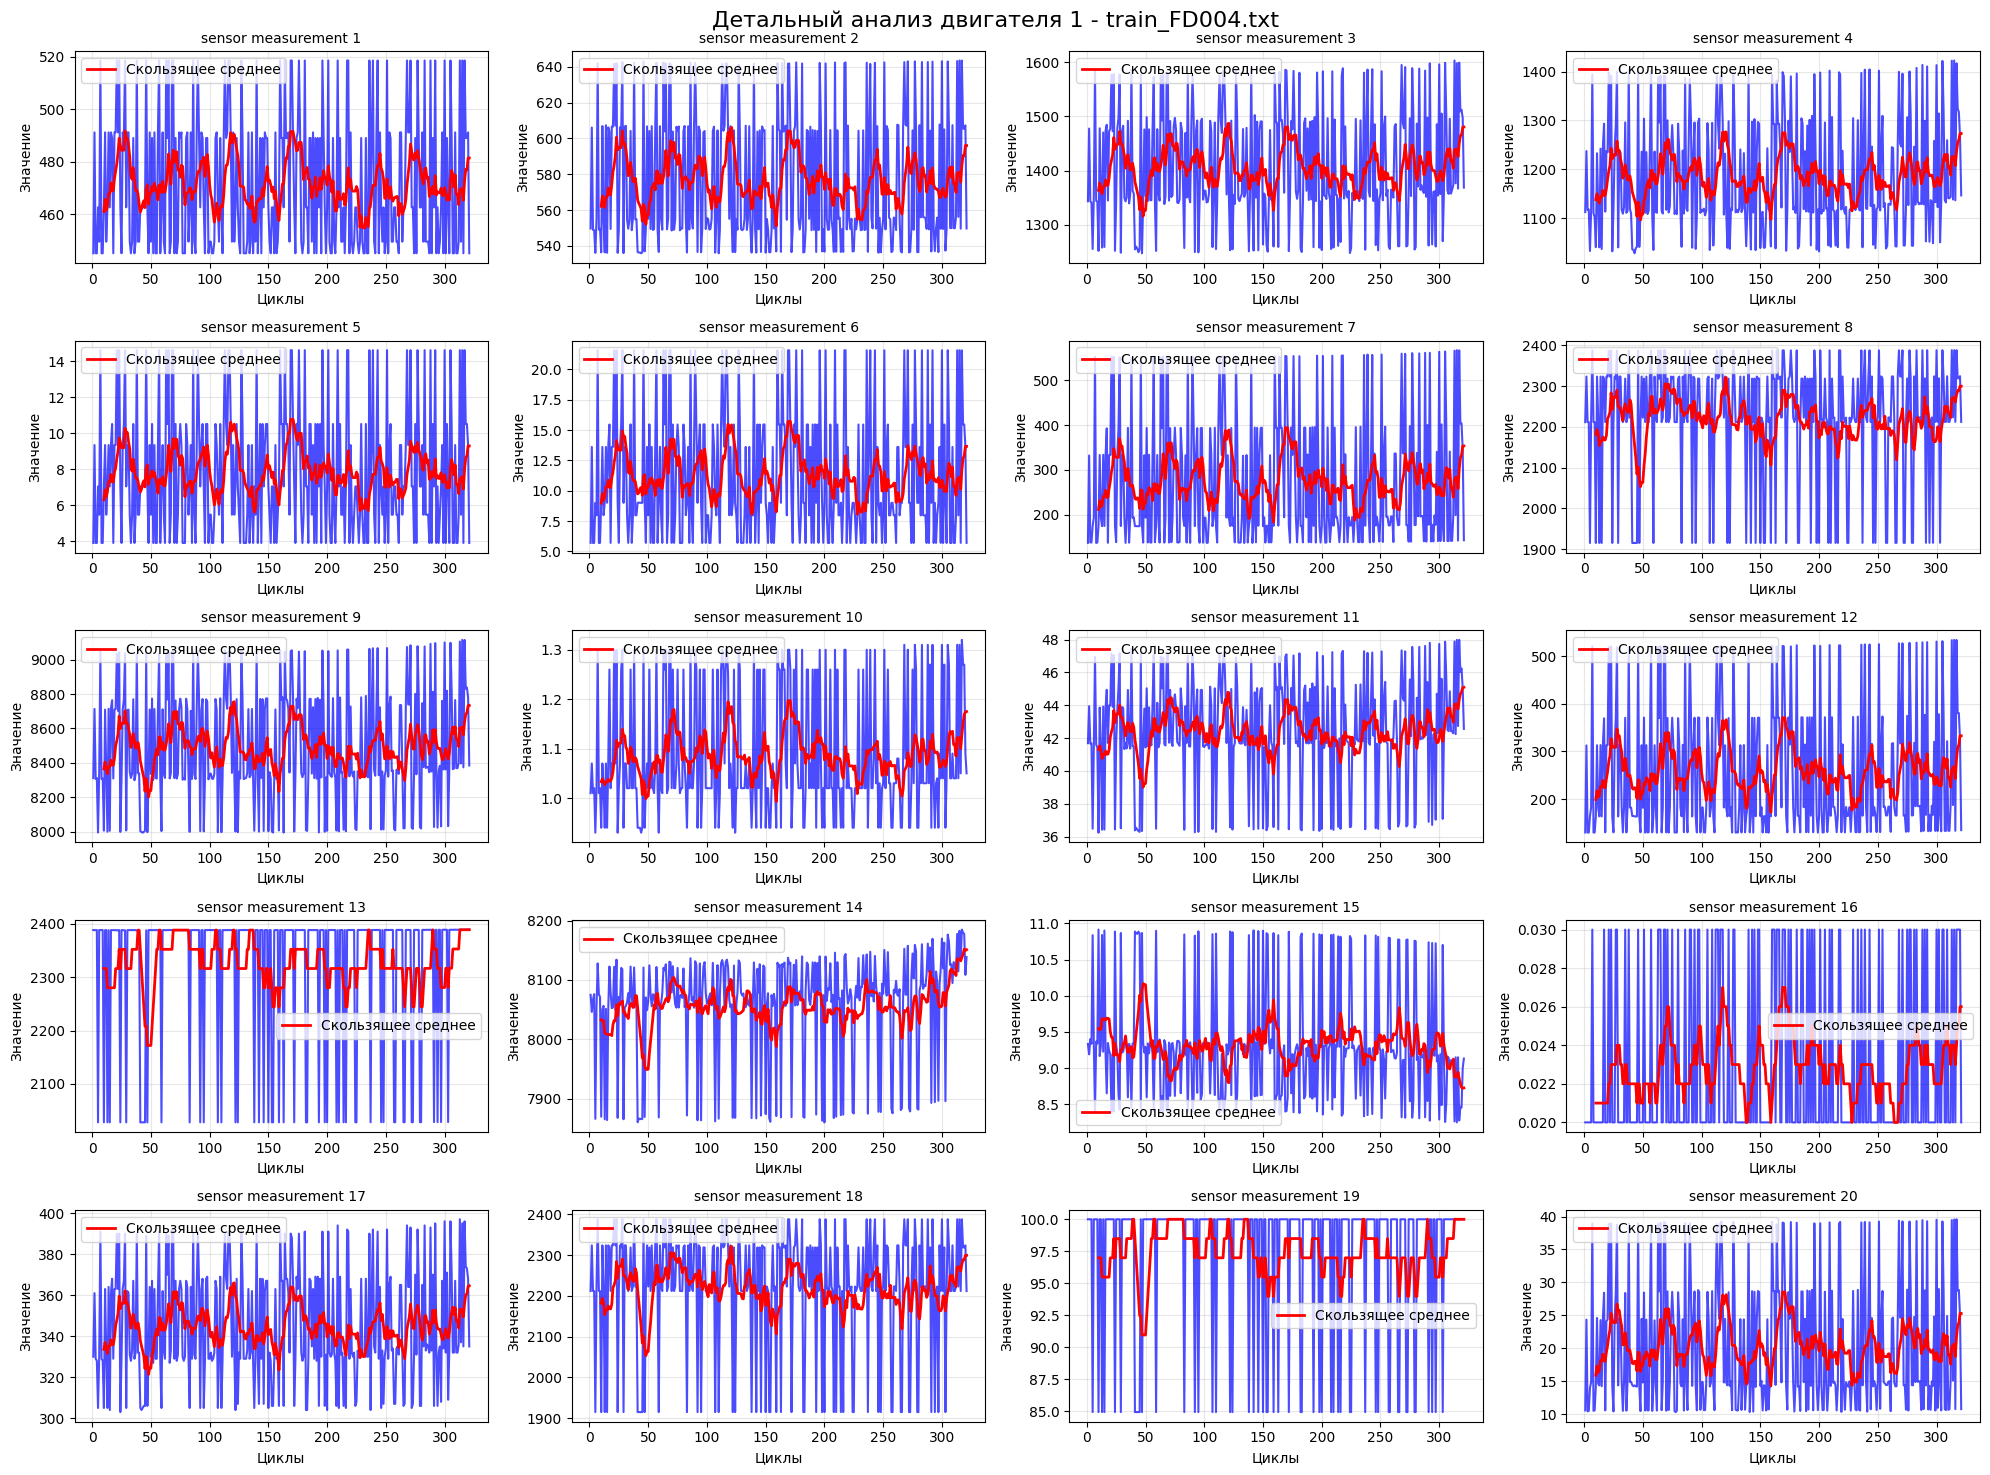

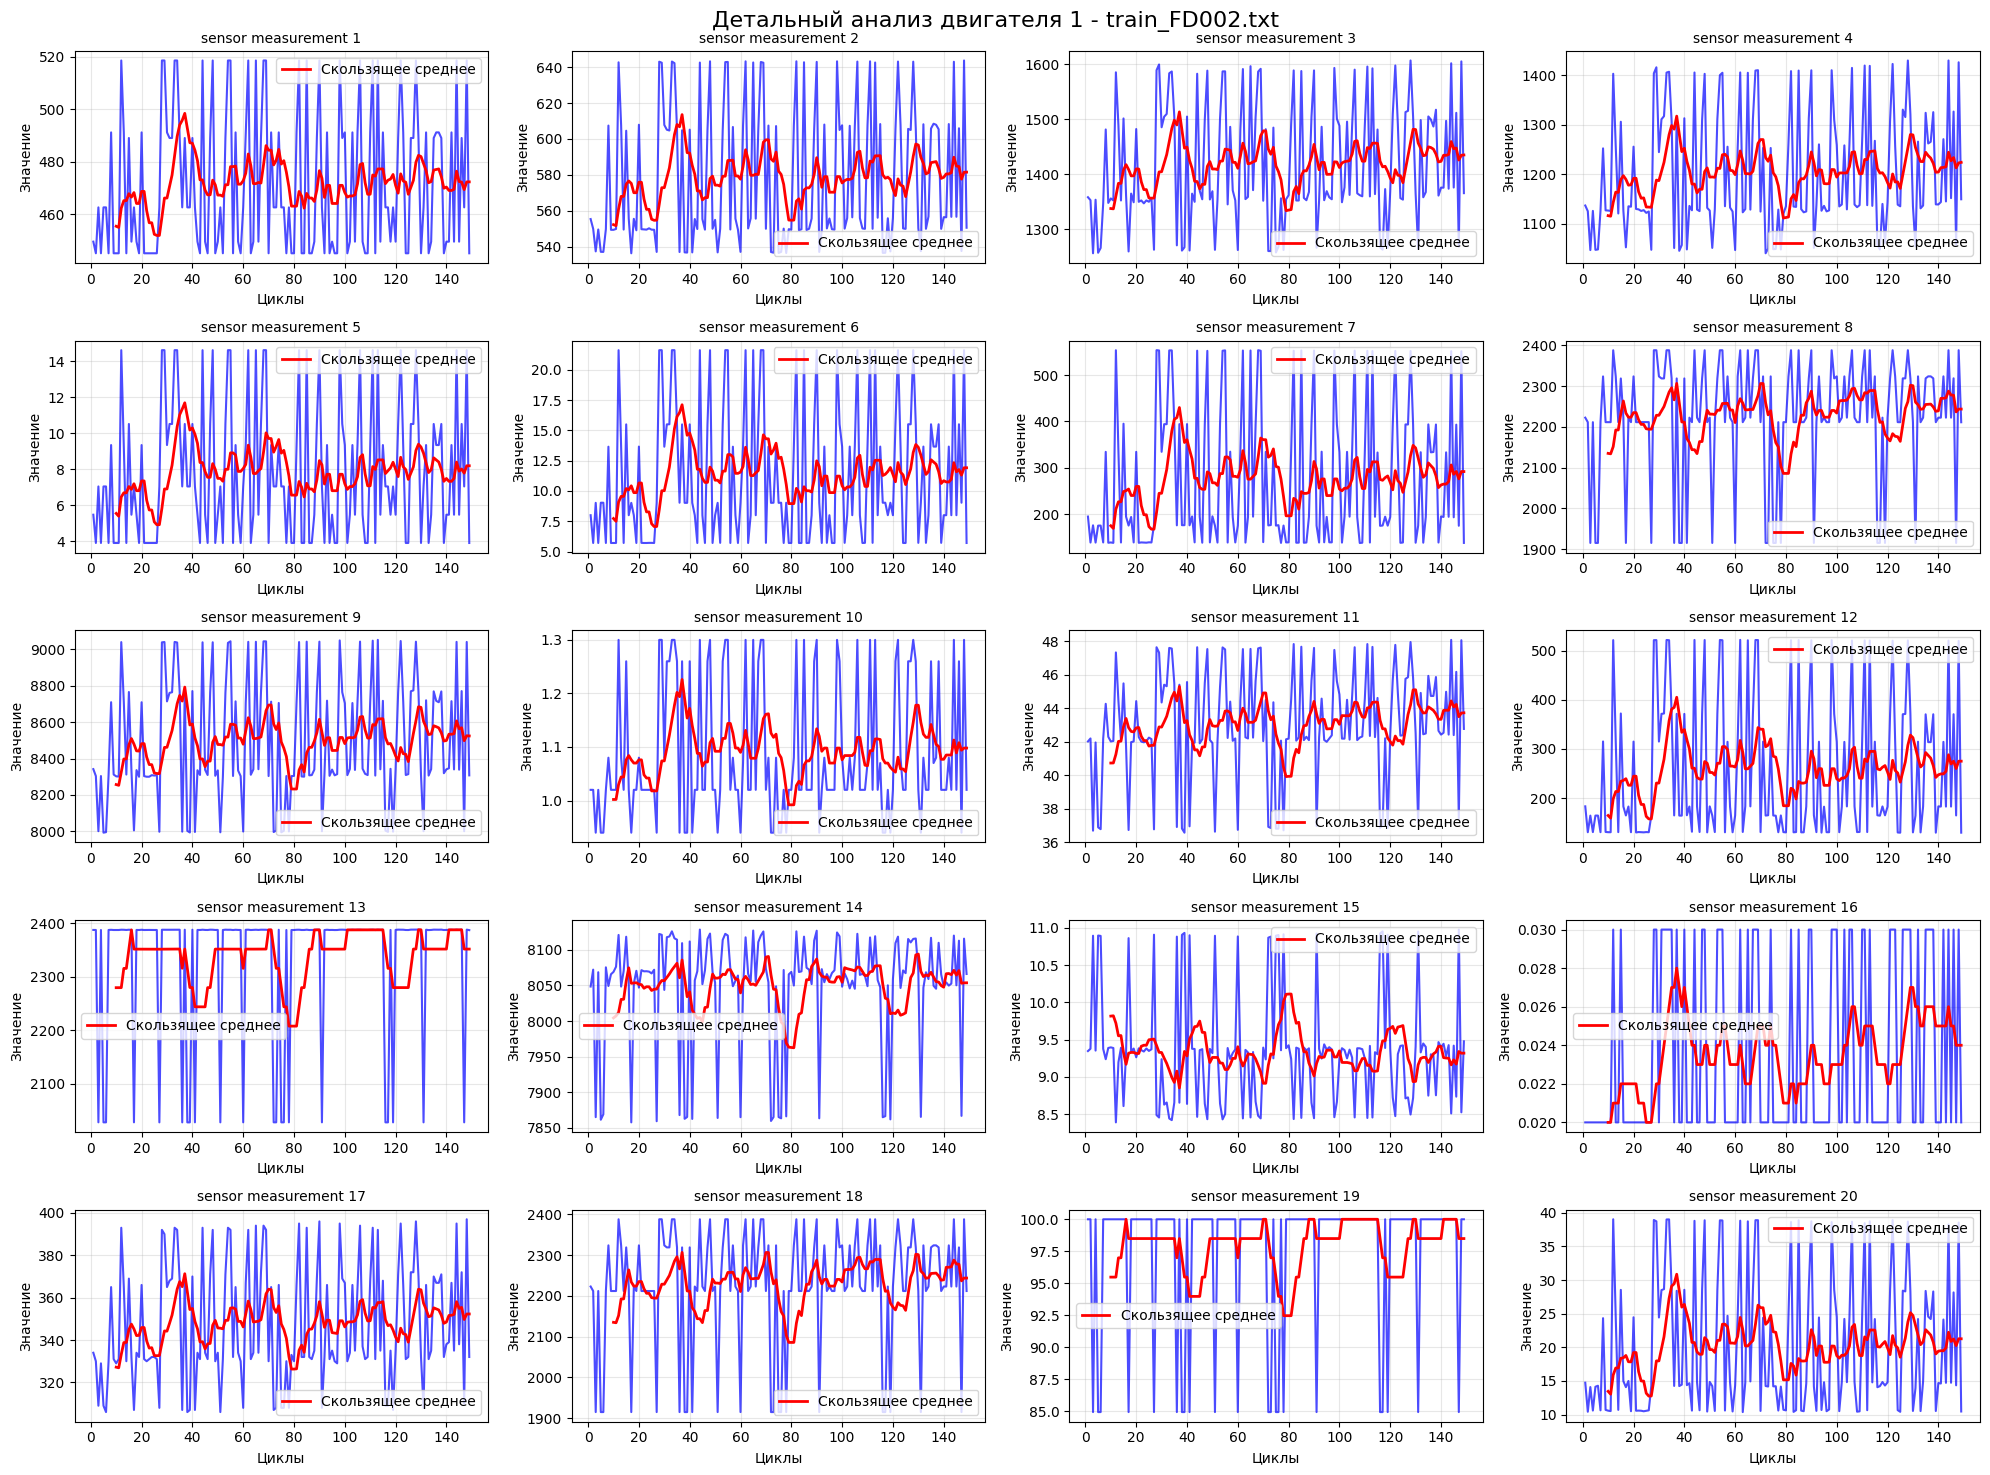

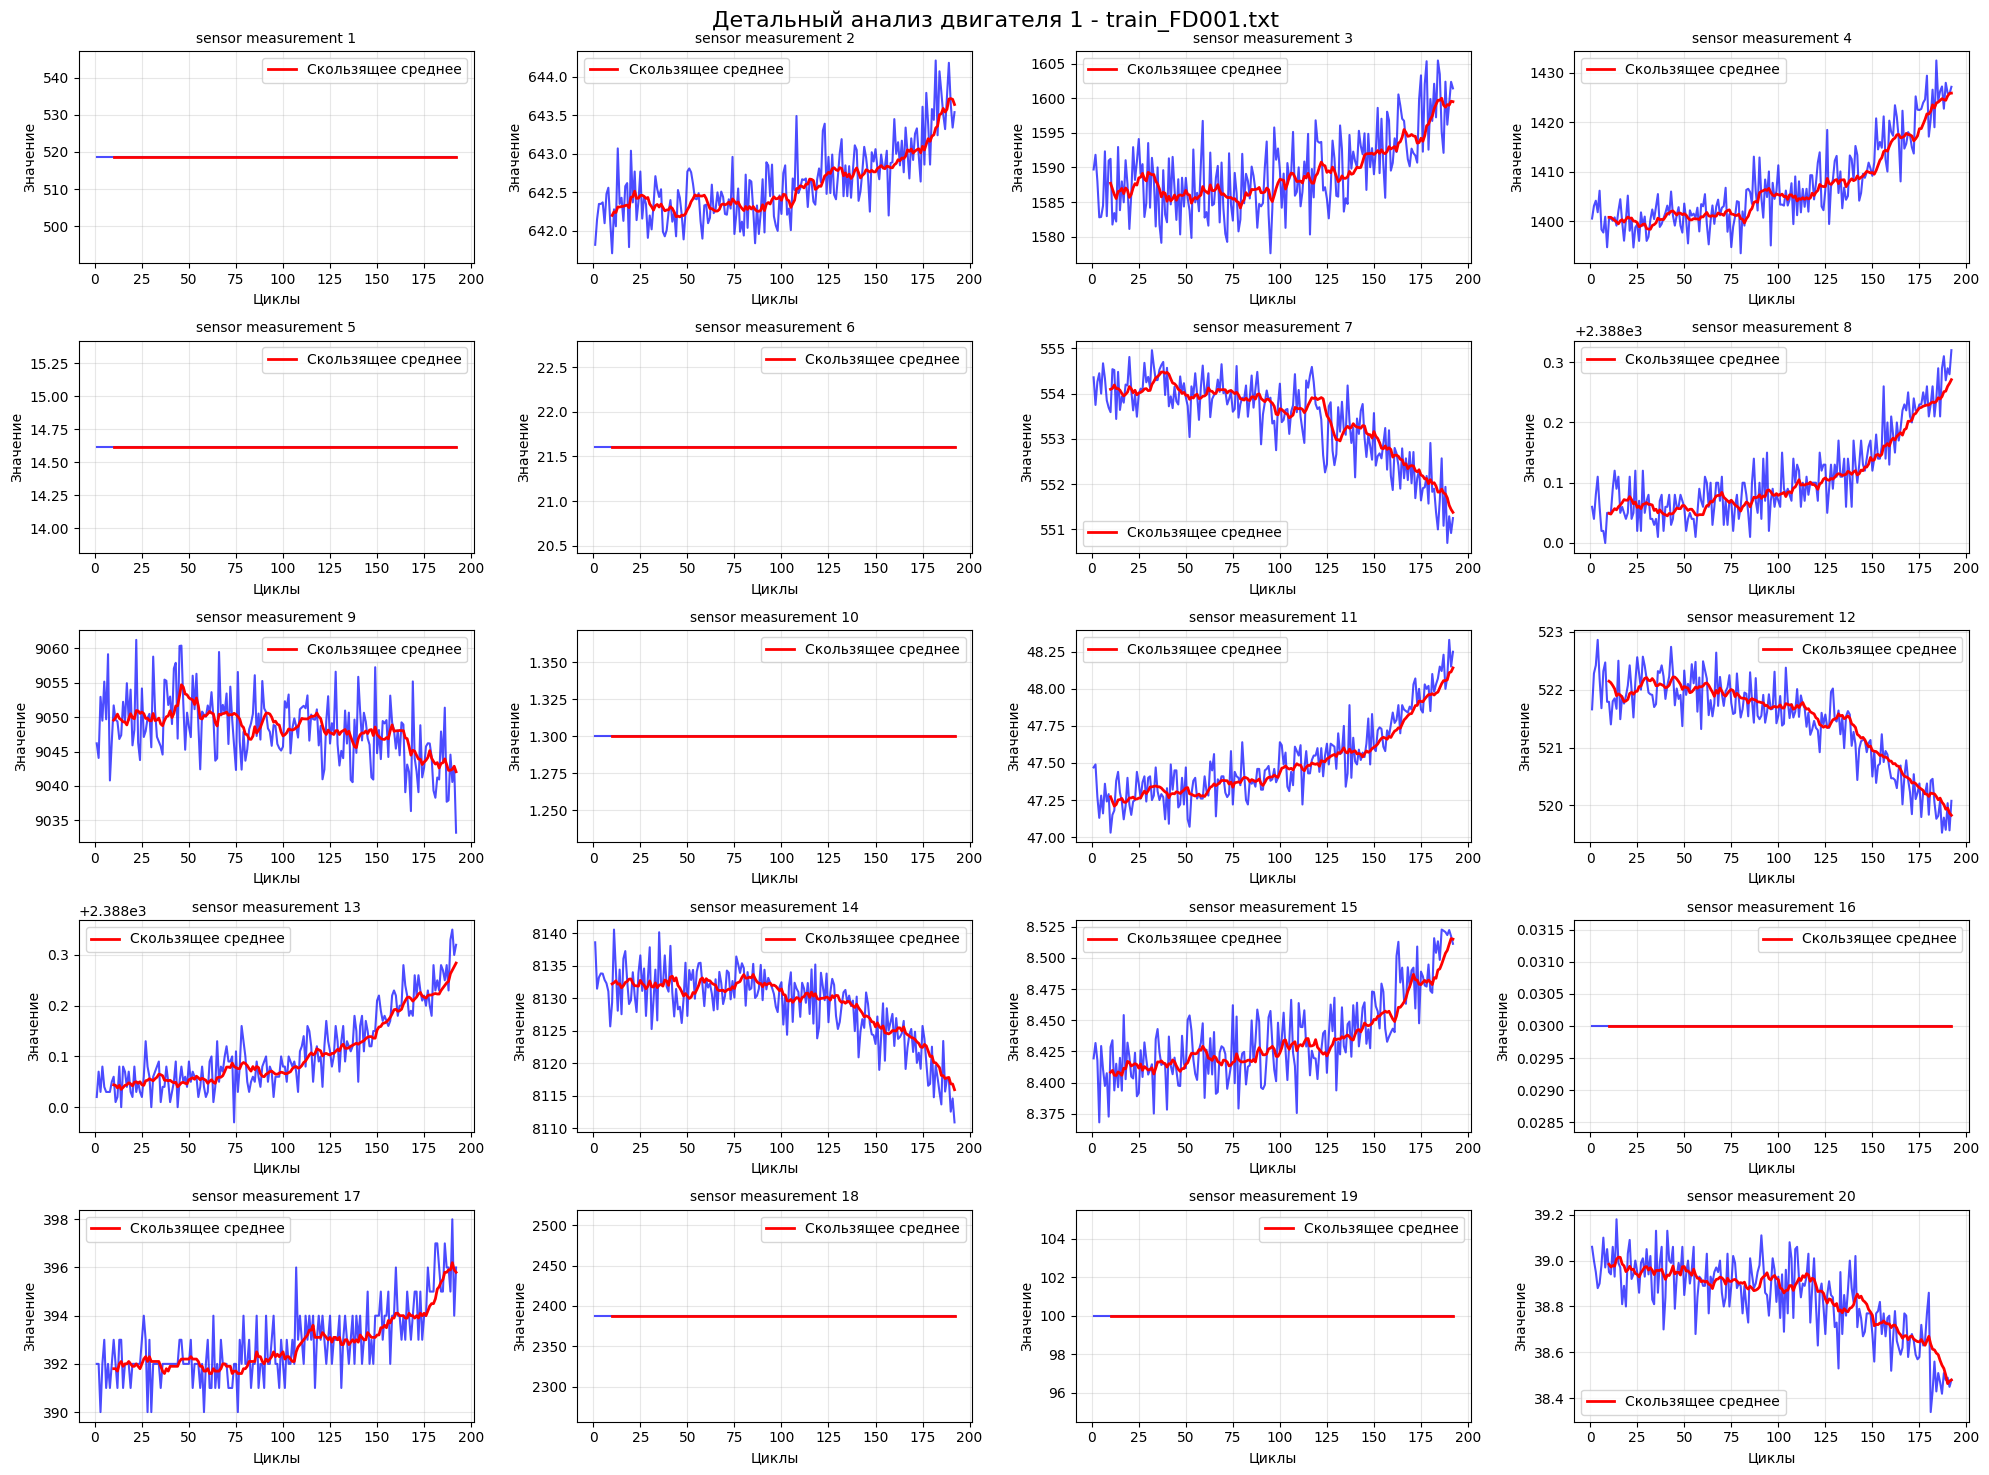

In [36]:
def detailed_unit_analysis(df, unit_number=1, dataset_name=""):
    """
    Детальный анализ всех сенсоров для одного двигателя
    """
    unit_data = df[df['unit number'] == unit_number]

    # Сенсоры для анализа (группируем по типам)
    sensor_cols = [col for col in df.columns if 'sensor' in col]

    # Создаем subplots
    fig, axes = plt.subplots(5, 4, figsize=(20, 15))
    fig.suptitle(f'Детальный анализ двигателя {unit_number} - {dataset_name}', fontsize=16)

    axes = axes.flatten()

    for i, sensor in enumerate(sensor_cols):
        if i < len(axes):
            ax = axes[i]

            # Основной тренд
            ax.plot(unit_data['time, in cycles'], unit_data[sensor],
                   color='blue', alpha=0.7, linewidth=1.5)

            # Скользящее среднее для сглаживания
            window_size = min(10, len(unit_data) // 5)
            if window_size > 1:
                rolling_mean = unit_data[sensor].rolling(window=window_size).mean()
                ax.plot(unit_data['time, in cycles'], rolling_mean,
                       color='red', linewidth=2, label='Скользящее среднее')

            ax.set_title(f'{sensor}', fontsize=10)
            ax.set_xlabel('Циклы')
            ax.set_ylabel('Значение')
            ax.grid(True, alpha=0.3)
            ax.legend()

    # Убираем лишние subplots
    for i in range(len(sensor_cols), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

    return unit_data

# Анализ конкретного двигателя
for name, df in datasets.items():
    if 'train' in name.lower() and 'unit number' in df.columns:
        detailed_unit_analysis(df, unit_number=1, dataset_name=name)

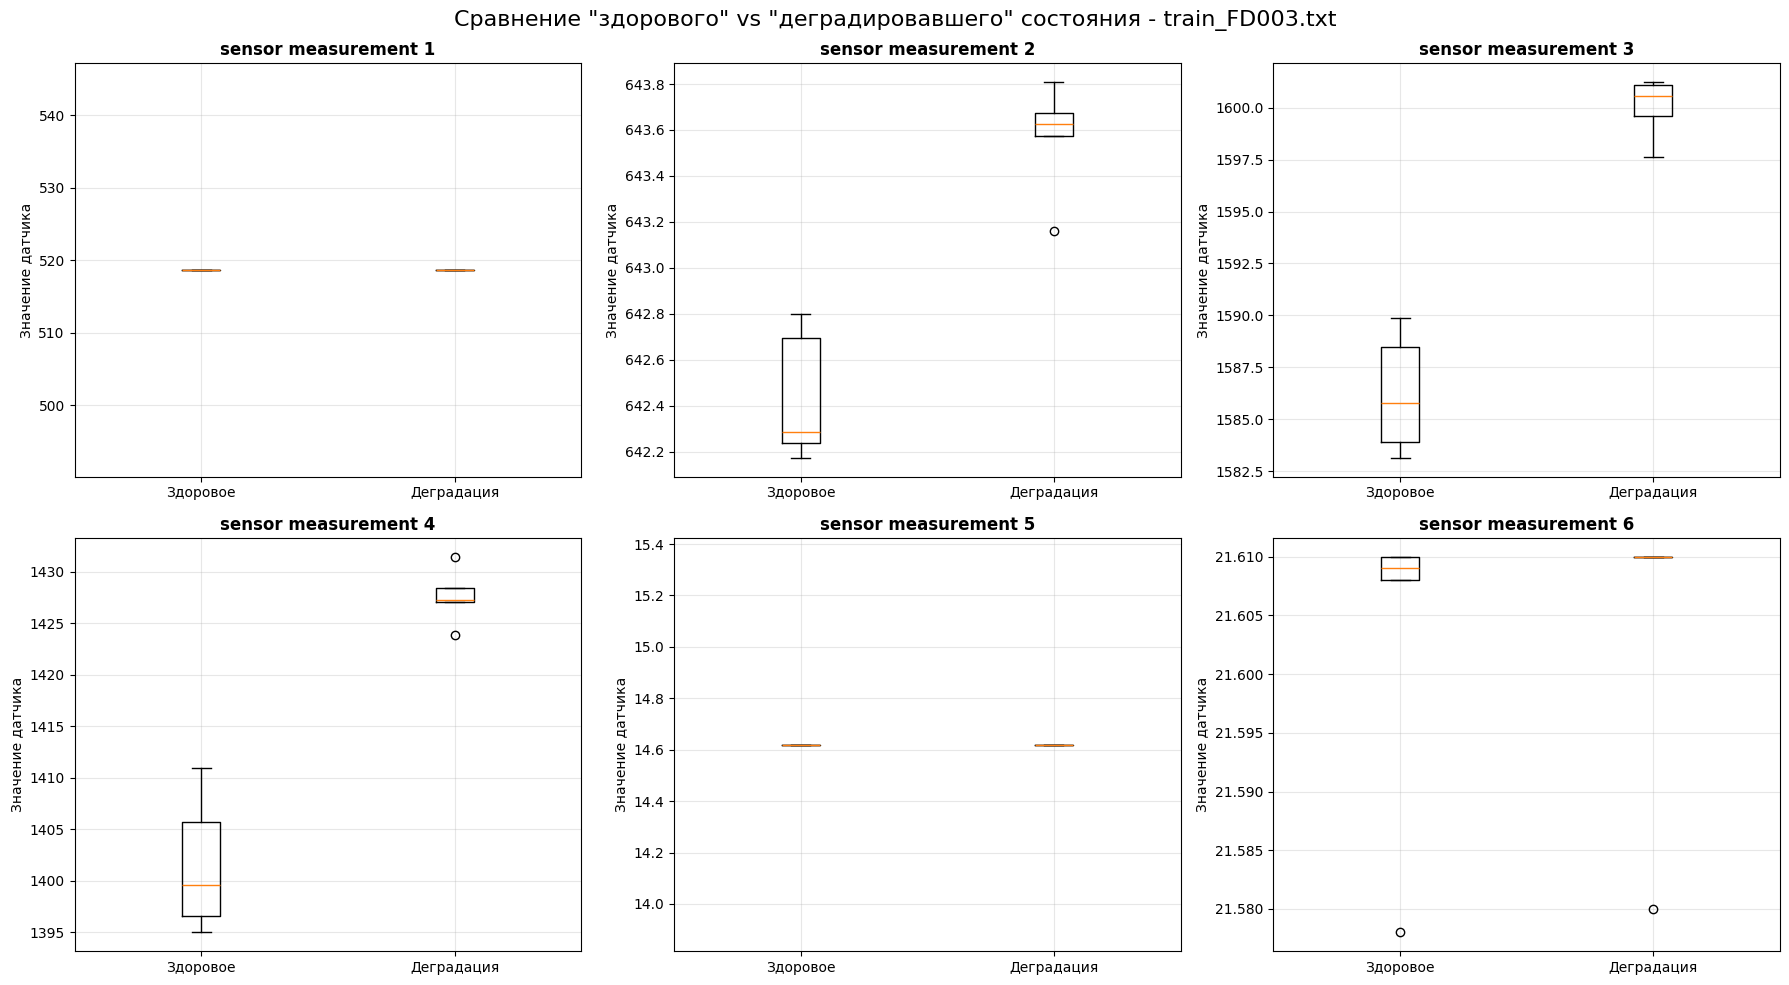

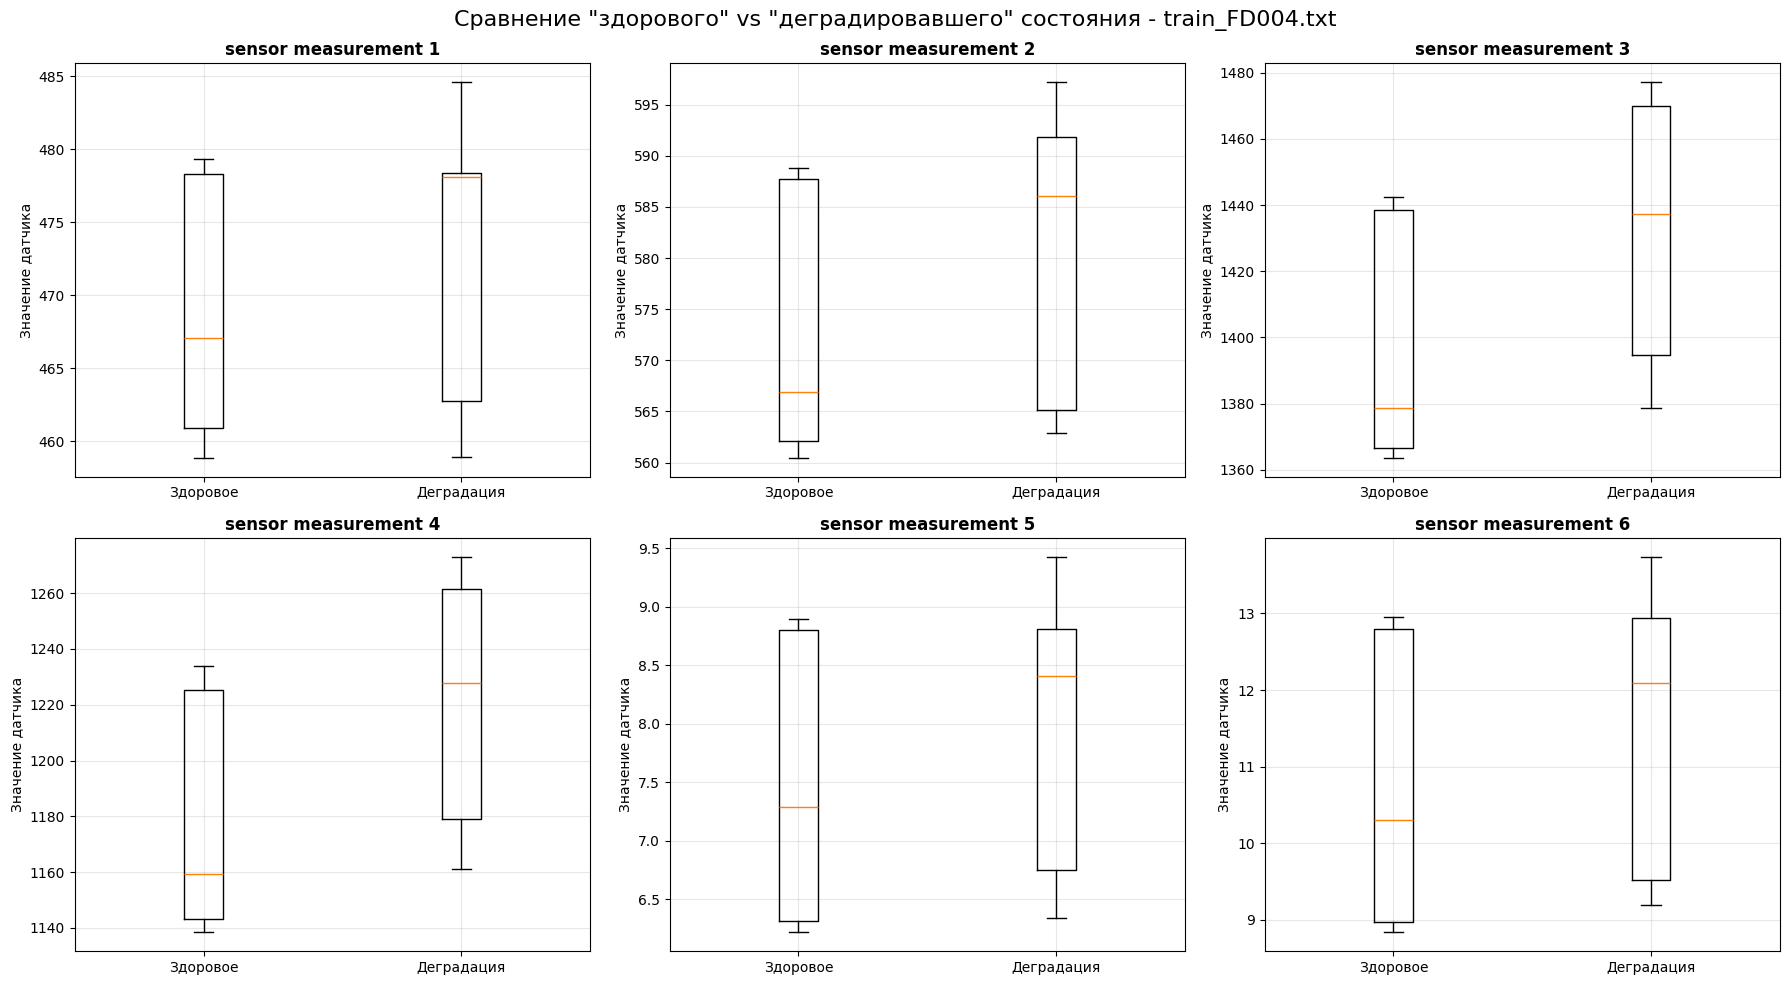

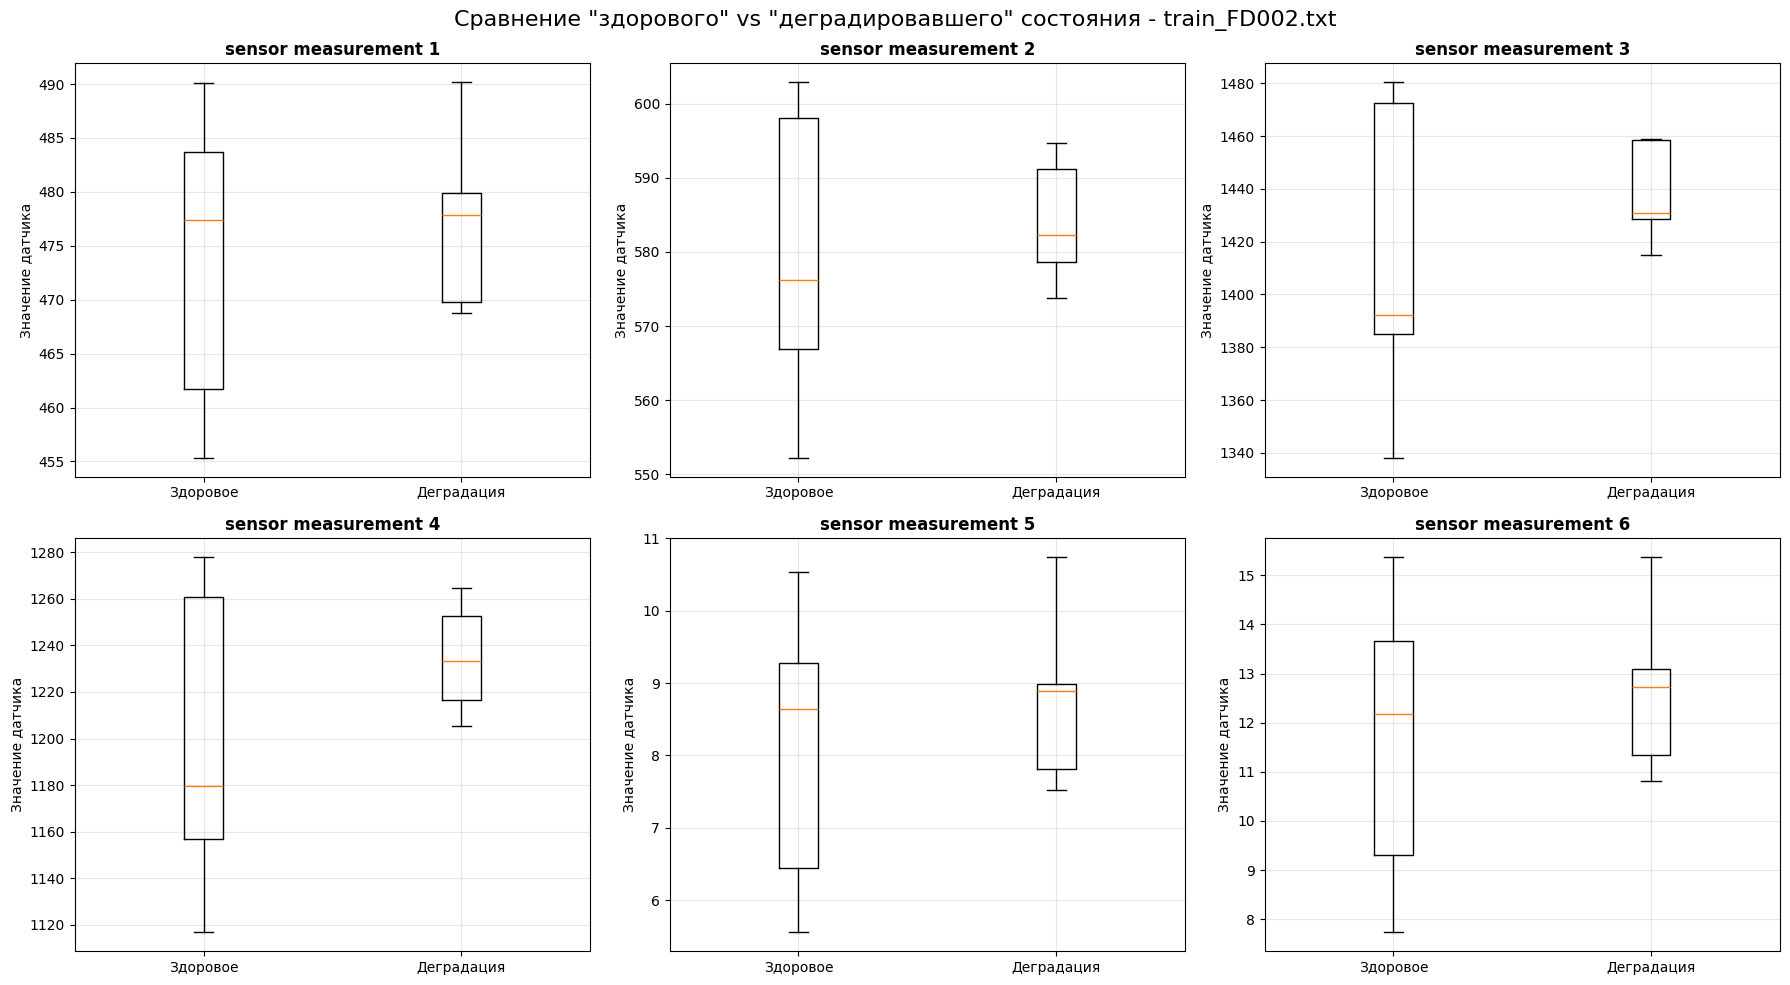

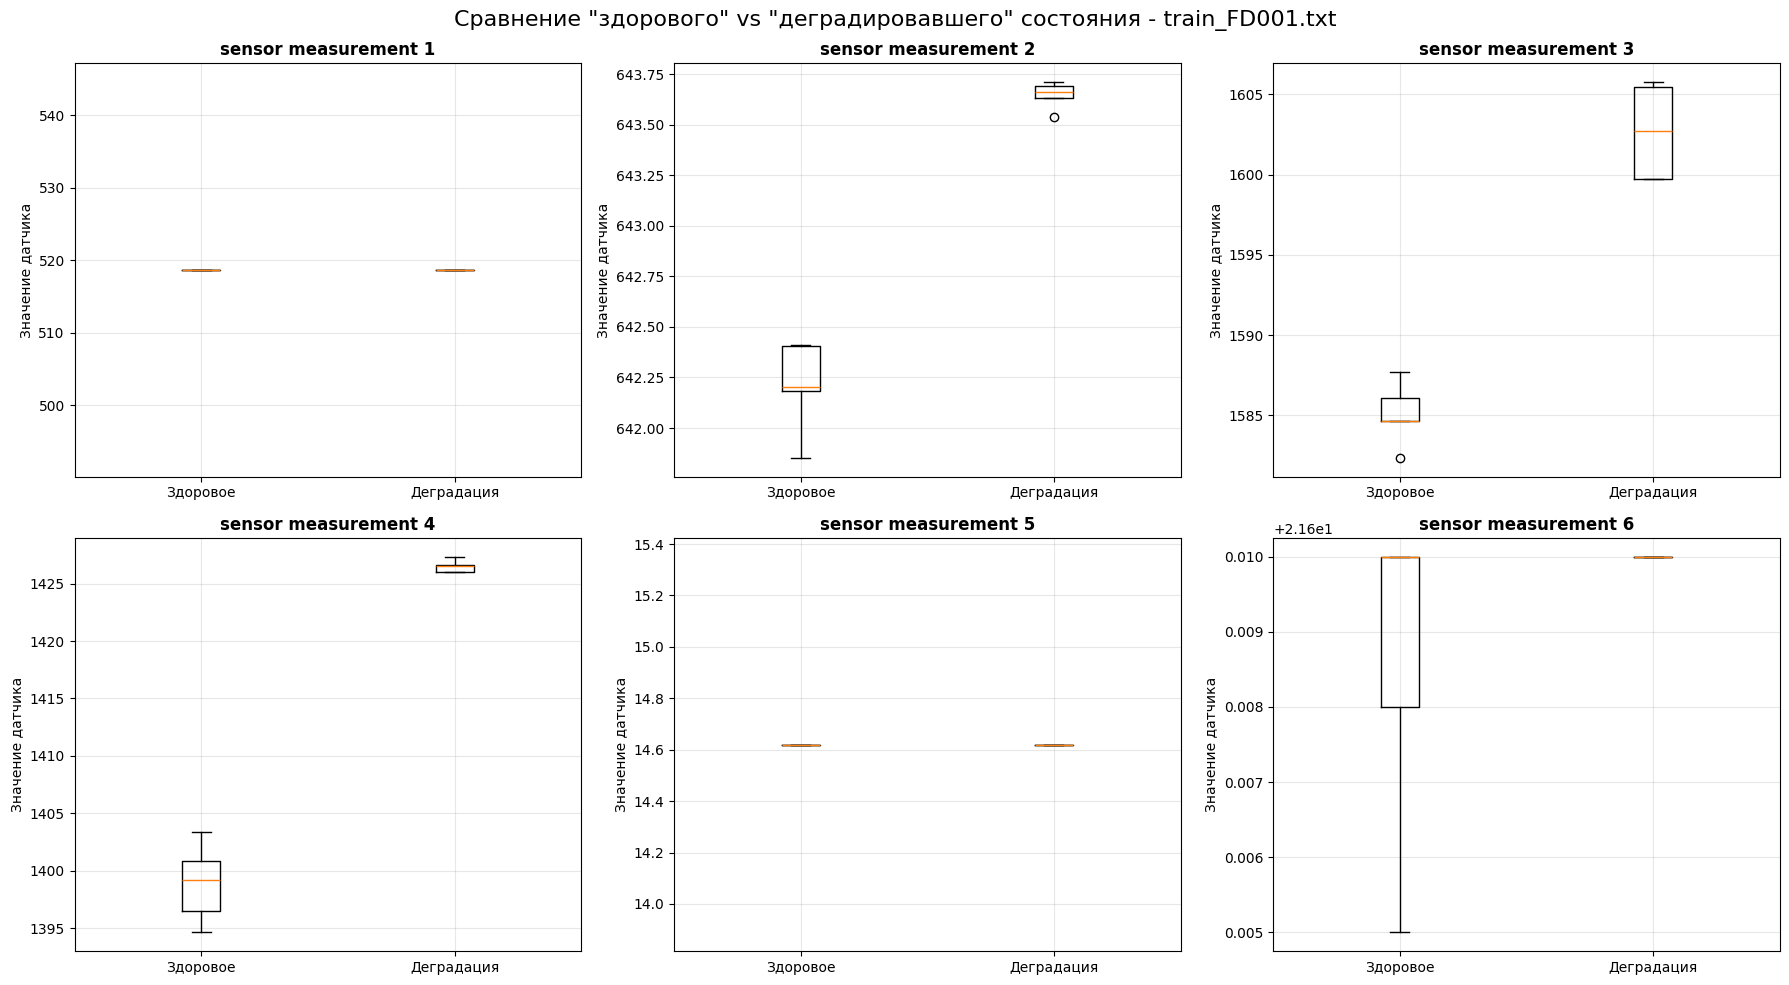

In [37]:
def compare_healthy_vs_degraded(df, dataset_name, healthy_cycle=10, degraded_cycle=-10):
    """
    Сравнение показаний датчиков в начале и конце жизни двигателей
    """
    # Выбираем несколько двигателей
    sample_units = df['unit number'].unique()[:5]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Сравнение "здорового" vs "деградировавшего" состояния - {dataset_name}',
                 fontsize=16)

    axes = axes.flatten()
    sensor_cols = [col for col in df.columns if 'sensor' in col][:6]

    for i, sensor in enumerate(sensor_cols):
        if i < len(axes):
            ax = axes[i]

            healthy_values = []
            degraded_values = []

            for unit_id in sample_units:
                unit_data = df[df['unit number'] == unit_id]

                # "Здоровое" состояние (первые циклы)
                healthy = unit_data[unit_data['time, in cycles'] <= healthy_cycle][sensor]
                if len(healthy) > 0:
                    healthy_values.append(healthy.mean())

                # "Деградировавшее" состояние (последние циклы)
                max_cycle = unit_data['time, in cycles'].max()
                degraded = unit_data[unit_data['time, in cycles'] >= (max_cycle + degraded_cycle)][sensor]
                if len(degraded) > 0:
                    degraded_values.append(degraded.mean())

            # Boxplot сравнение
            data_to_plot = [healthy_values, degraded_values]
            ax.boxplot(data_to_plot, tick_labels=['Здоровое', 'Деградация'])
            ax.set_title(f'{sensor}', fontweight='bold')
            ax.set_ylabel('Значение датчика')
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Применяем сравнение
for name, df in datasets.items():
    if 'train' in name.lower() and 'unit number' in df.columns:
        compare_healthy_vs_degraded(df, name)

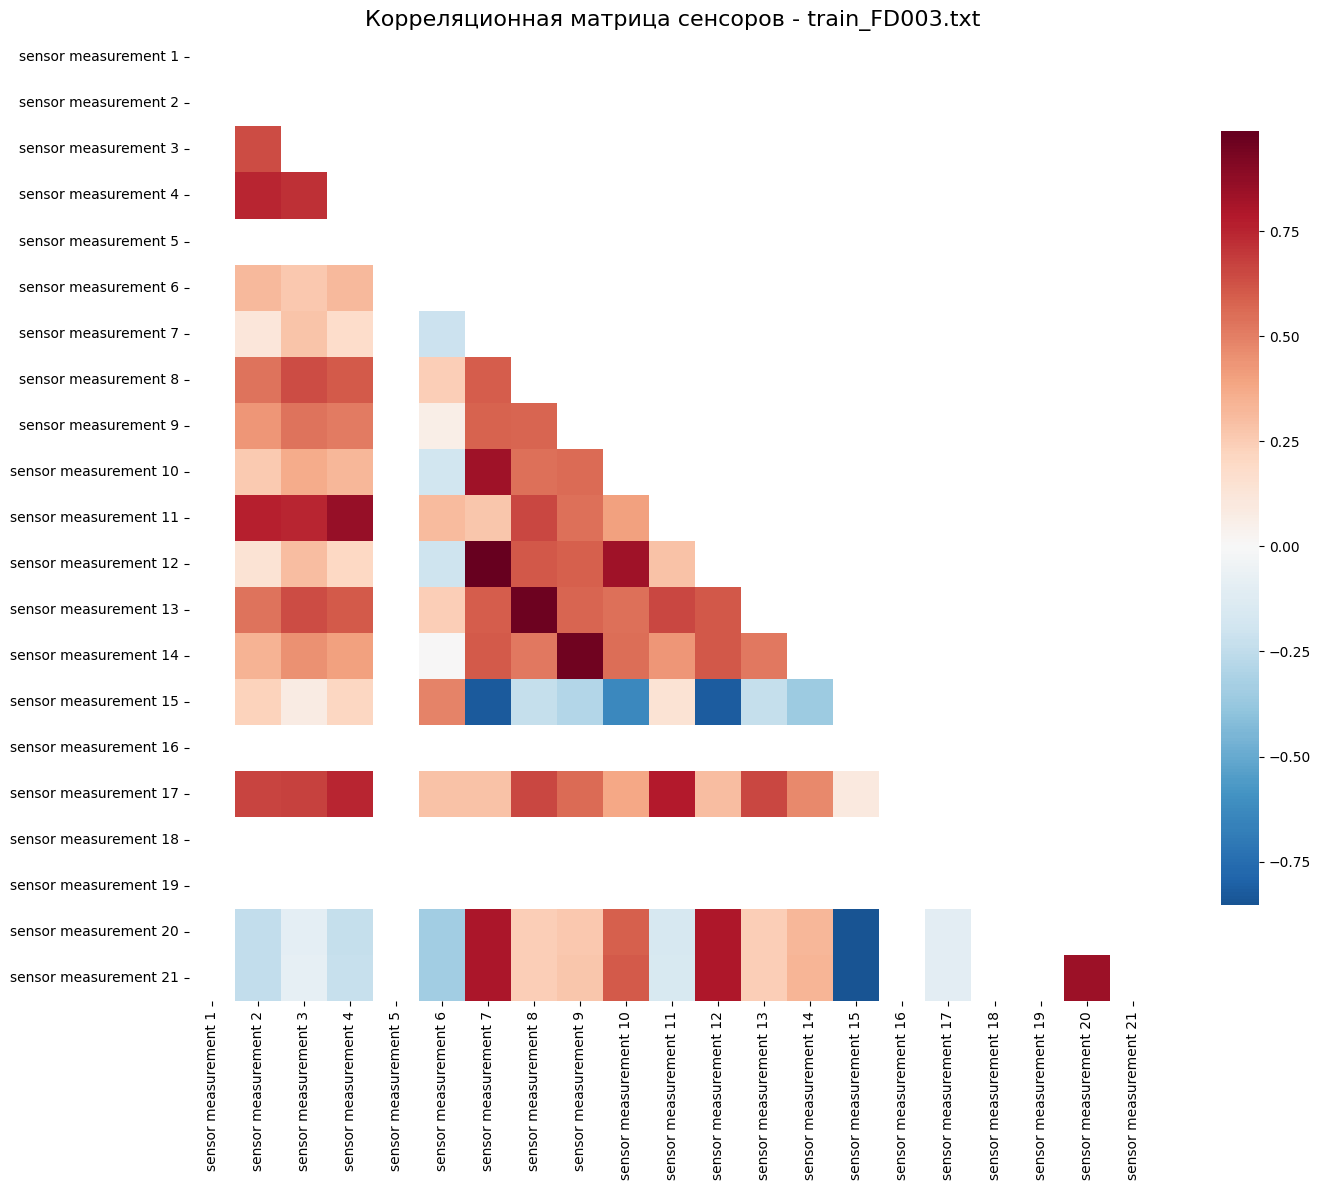

Наиболее коррелирующие пары сенсоров:
sensor measurement 7   sensor measurement 12    0.988725
sensor measurement 12  sensor measurement 7     0.988725
sensor measurement 13  sensor measurement 8     0.964052
sensor measurement 8   sensor measurement 13    0.964052
sensor measurement 9   sensor measurement 14    0.954354
sensor measurement 14  sensor measurement 9     0.954354
sensor measurement 11  sensor measurement 4     0.854030
sensor measurement 4   sensor measurement 11    0.854030
sensor measurement 15  sensor measurement 21   -0.852349
sensor measurement 21  sensor measurement 15   -0.852349
dtype: float64


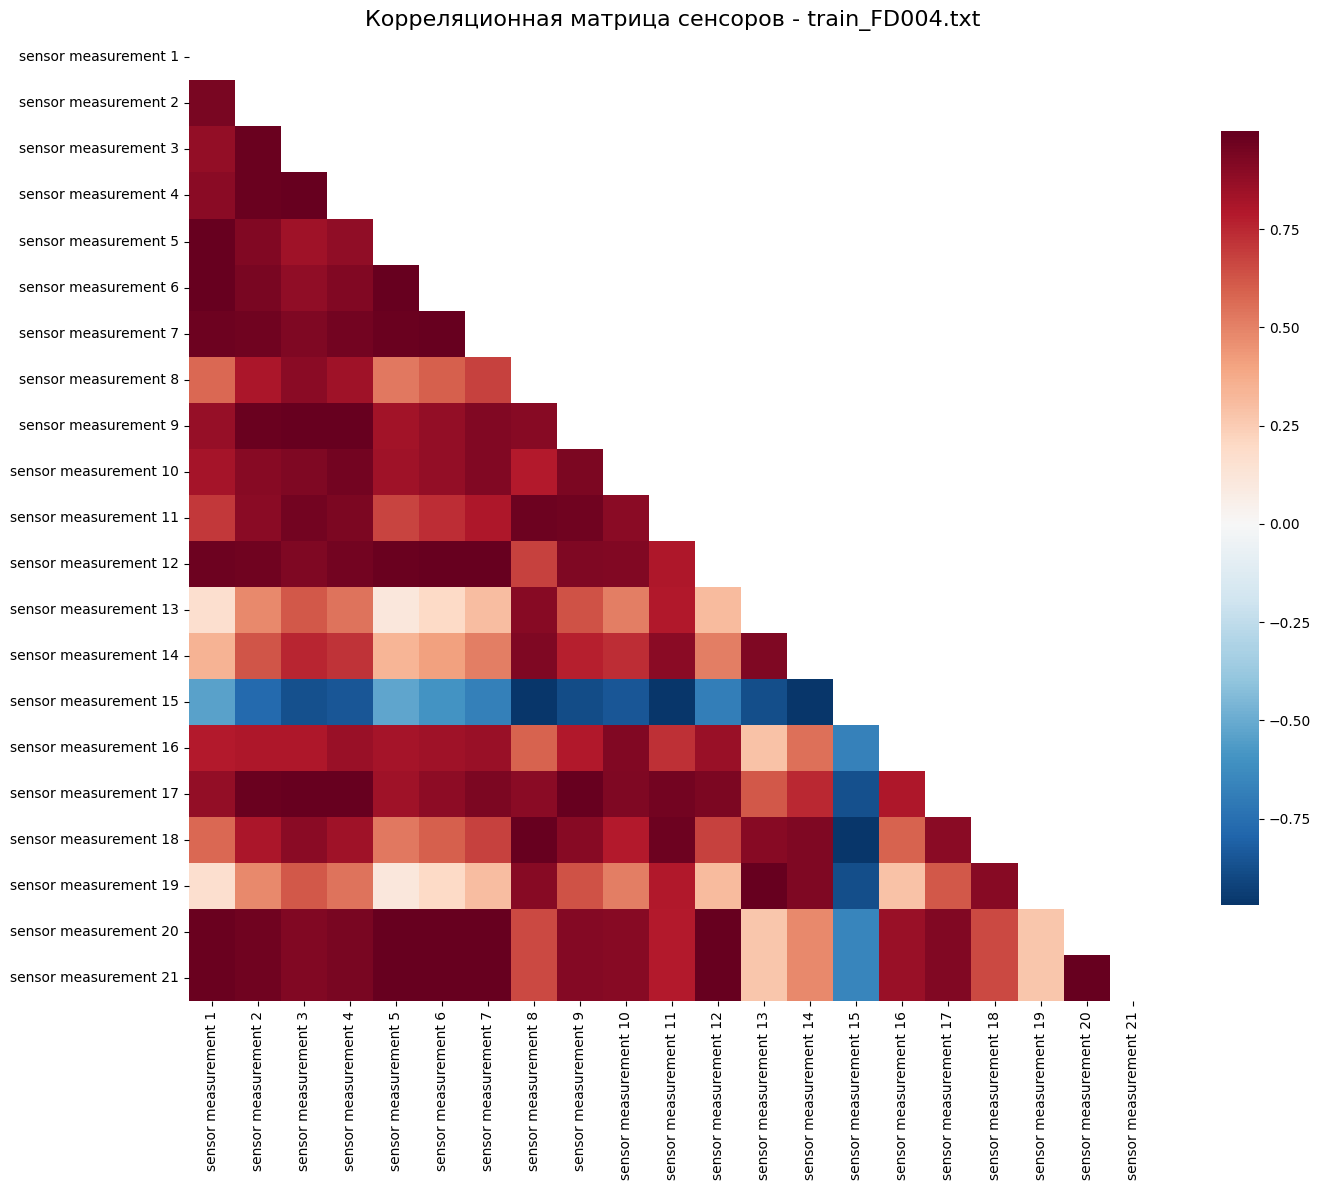

Наиболее коррелирующие пары сенсоров:
sensor measurement 8   sensor measurement 18    0.999999
sensor measurement 18  sensor measurement 8     0.999999
sensor measurement 19  sensor measurement 13    0.999998
sensor measurement 13  sensor measurement 19    0.999998
sensor measurement 7   sensor measurement 12    0.999993
sensor measurement 12  sensor measurement 7     0.999993
sensor measurement 20  sensor measurement 21    0.999897
sensor measurement 21  sensor measurement 20    0.999897
sensor measurement 20  sensor measurement 7     0.999142
sensor measurement 7   sensor measurement 20    0.999142
dtype: float64


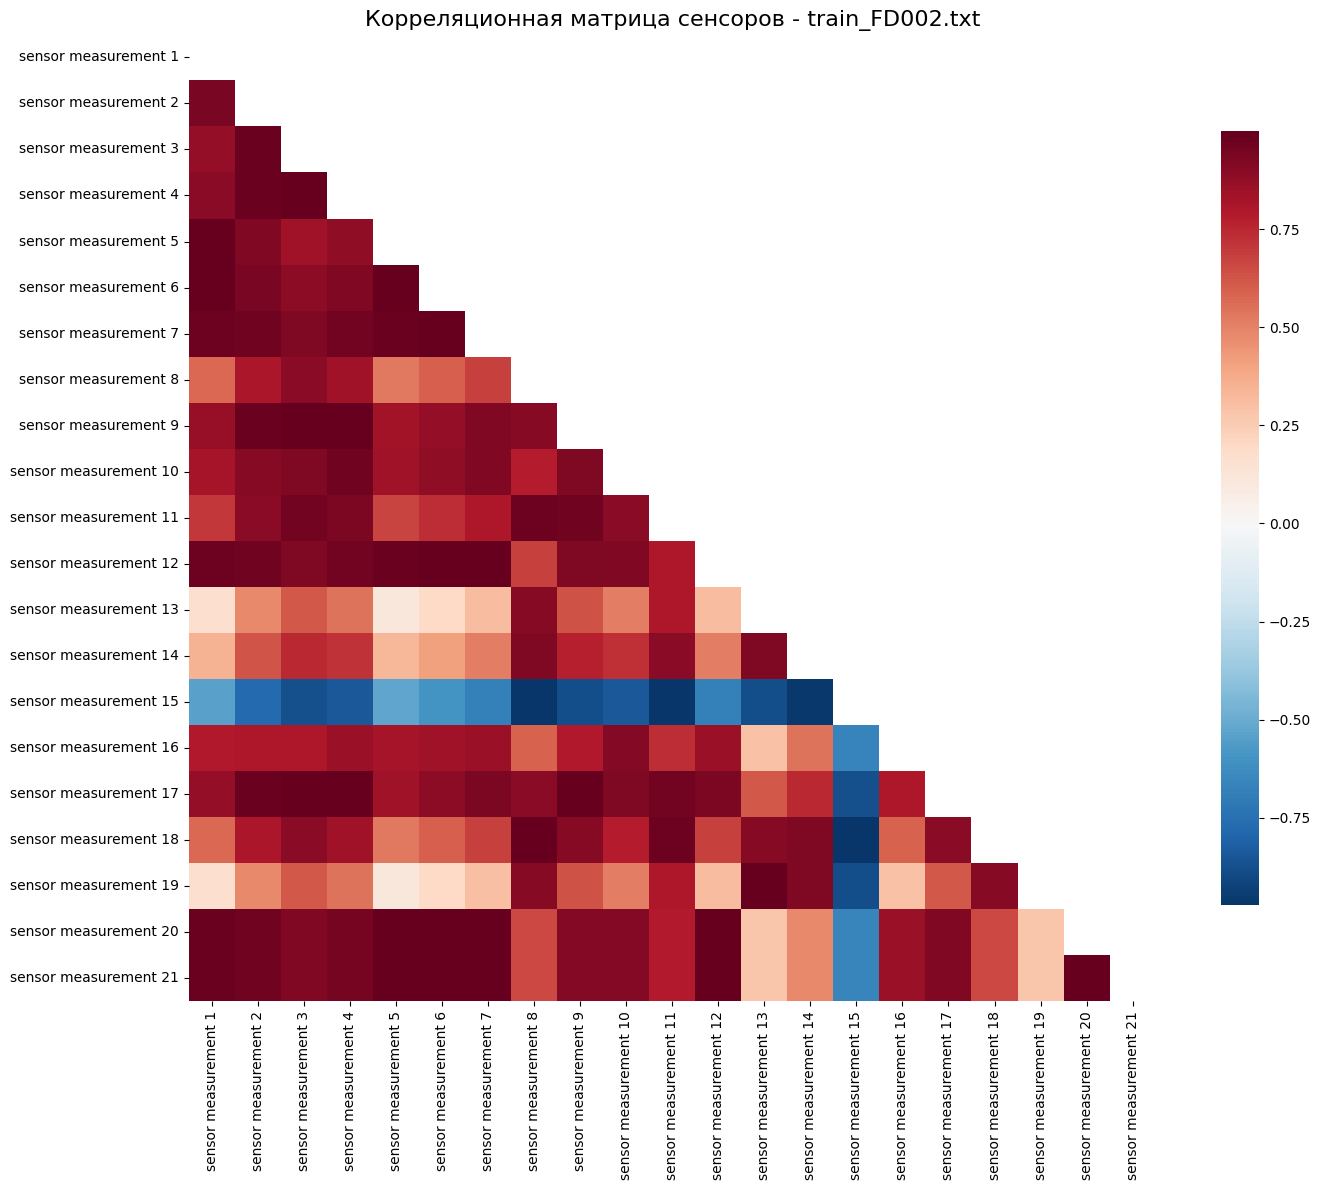

Наиболее коррелирующие пары сенсоров:
sensor measurement 8   sensor measurement 18    0.999999
sensor measurement 18  sensor measurement 8     0.999999
sensor measurement 19  sensor measurement 13    0.999998
sensor measurement 13  sensor measurement 19    0.999998
sensor measurement 7   sensor measurement 12    0.999993
sensor measurement 12  sensor measurement 7     0.999993
sensor measurement 20  sensor measurement 21    0.999898
sensor measurement 21  sensor measurement 20    0.999898
sensor measurement 20  sensor measurement 7     0.999146
sensor measurement 7   sensor measurement 20    0.999146
dtype: float64


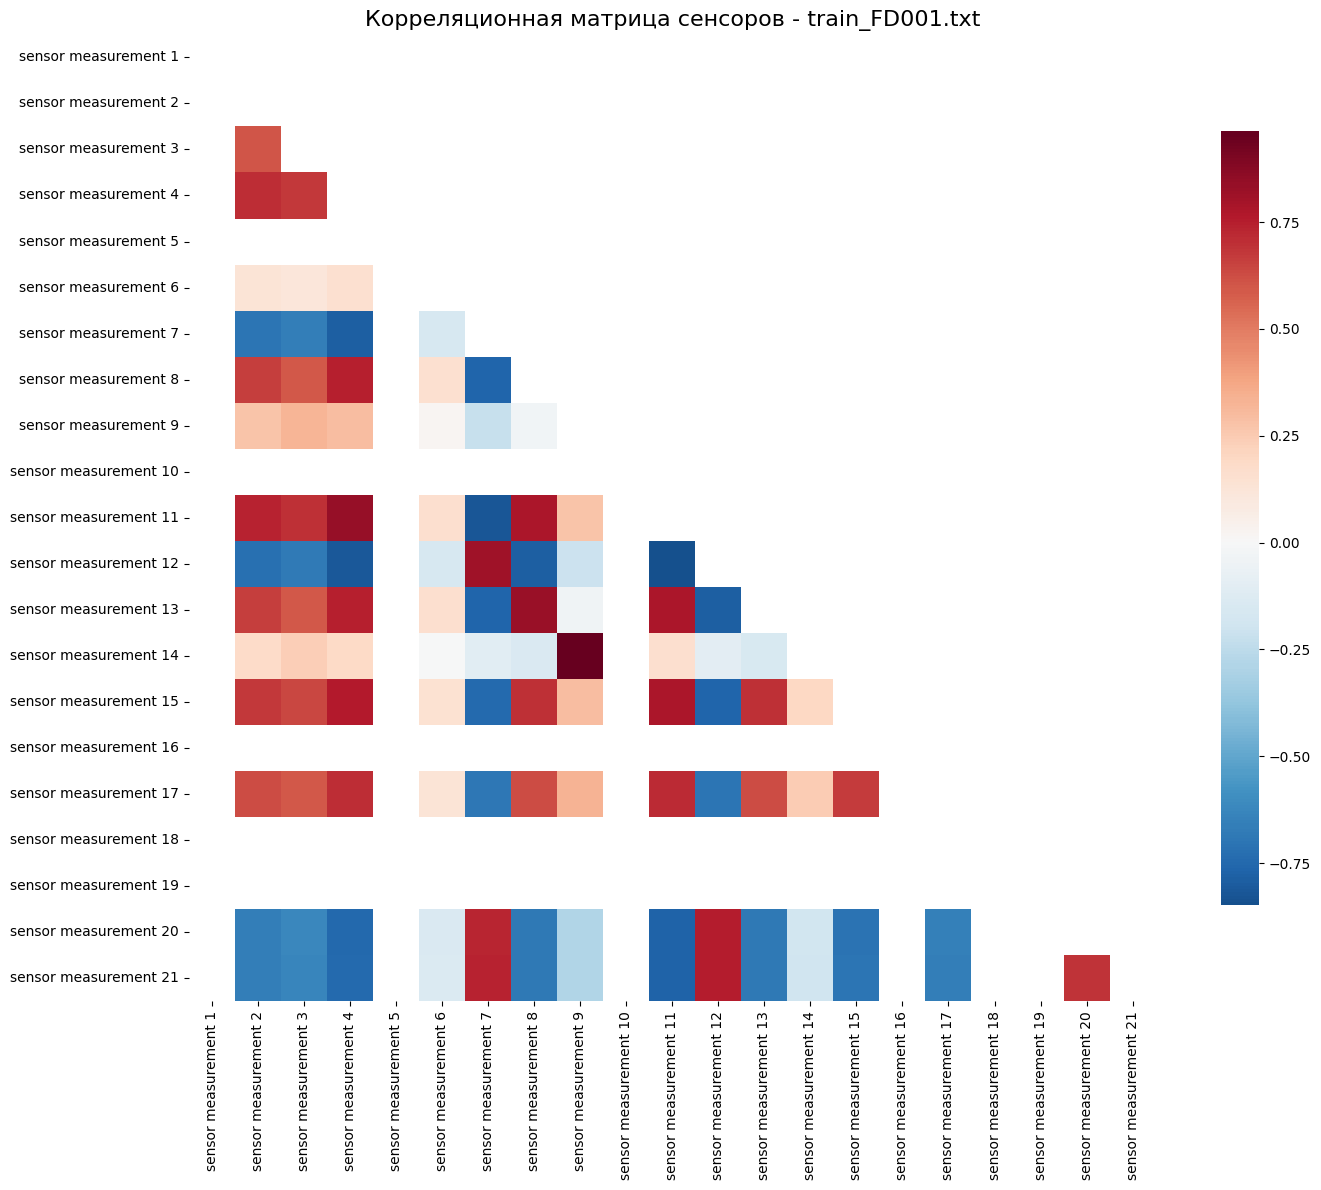

Наиболее коррелирующие пары сенсоров:
sensor measurement 14  sensor measurement 9     0.963157
sensor measurement 9   sensor measurement 14    0.963157
sensor measurement 11  sensor measurement 12   -0.846884
sensor measurement 12  sensor measurement 11   -0.846884
sensor measurement 4   sensor measurement 11    0.830136
sensor measurement 11  sensor measurement 4     0.830136
sensor measurement 13  sensor measurement 8     0.826084
sensor measurement 8   sensor measurement 13    0.826084
sensor measurement 7   sensor measurement 11   -0.822805
sensor measurement 11  sensor measurement 7    -0.822805
dtype: float64


In [38]:
def sensor_correlation_heatmap(df, dataset_name):
    """
    Тепловая карта корреляций между сенсорами
    """
    sensor_cols = [col for col in df.columns if 'sensor' in col]

    plt.figure(figsize=(15, 12))
    correlation_matrix = df[sensor_cols].corr()

    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Маска для верхнего треугольника

    sns.heatmap(correlation_matrix,
                mask=mask,
                cmap='RdBu_r',
                center=0,
                annot=False,  # Убрать аннотации для читаемости
                square=True,
                cbar_kws={"shrink": .8})

    plt.title(f'Корреляционная матрица сенсоров - {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Выводим наиболее коррелирующие пары
    print("Наиболее коррелирующие пары сенсоров:")
    corr_pairs = correlation_matrix.unstack().sort_values(key=abs, ascending=False)
    highly_correlated = corr_pairs[(corr_pairs != 1.0) & (corr_pairs.abs() > 0.8)]
    print(highly_correlated.head(10))

# Строим heatmap для каждого датасета
for name, df in datasets.items():
    if 'train' in name.lower():
        sensor_cols = [col for col in df.columns if 'sensor' in col]
        if len(sensor_cols) > 0:
            sensor_correlation_heatmap(df, name)

#Задача 2. Предварительная обработка данных

- Обработать пропущенные значения и нормализовать данные датчиков
- Сформировать целевые метки RUL для обучающих данных
- Создать признаки на основе скользящего окна (sliding window features) для
временных рядов
- Разделить данные на обучающую и валидационную выборки (80/20)

In [61]:
# выявим и удалим неинформативные колонки

train_data = [f for f in datasets.keys() if 'train' in f.lower()]
test_data = [f for f in datasets.keys() if 'test' in f.lower()]

non_informative_sensors = []

def df_cleaner(data_files):

    data_files_cleaned = {}

    for file_name in data_files:
      df = datasets[file_name]
      print(f'\nФайл: {file_name}')
      for col in df:
          if df[col].std() == 0:
              non_informative_sensors.append(col)
              print(f"Колонка {col} имеет нулевое стандартное отклонение и будет удалена.")

      print("Неинформативные колонки:", non_informative_sensors)
      df_cleaned = df.drop(columns=non_informative_sensors)
      data_files_cleaned[file_name] = df_cleaned


    return data_files_cleaned

train_data_cleaned = df_cleaner(train_data)
test_data_cleaned = df_cleaner(test_data)


Файл: train_FD003.txt
Колонка operational setting 3 имеет нулевое стандартное отклонение и будет удалена.
Колонка sensor measurement 18 имеет нулевое стандартное отклонение и будет удалена.
Колонка sensor measurement 19 имеет нулевое стандартное отклонение и будет удалена.
Неинформативные колонки: ['operational setting 3', 'sensor measurement 18', 'sensor measurement 19']

Файл: train_FD004.txt
Неинформативные колонки: ['operational setting 3', 'sensor measurement 18', 'sensor measurement 19']

Файл: train_FD001.txt
Колонка operational setting 3 имеет нулевое стандартное отклонение и будет удалена.
Колонка sensor measurement 18 имеет нулевое стандартное отклонение и будет удалена.
Колонка sensor measurement 19 имеет нулевое стандартное отклонение и будет удалена.
Неинформативные колонки: ['operational setting 3', 'sensor measurement 18', 'sensor measurement 19', 'operational setting 3', 'sensor measurement 18', 'sensor measurement 19']

Файл: train_FD002.txt
Неинформативные колонки: [

In [65]:
# Выполним нормализацию данных
cols_to_normalize = [col for col in column_names if col not in ['unit number', 'time, in cycles']]

# Создадим scaler и словари для результатов
scaler = StandardScaler()
train_data_normalized = {}
test_data_normalized = {}

# Собираем все тренировочные данные
all_train_data = []
for file_name, df in train_data_cleaned.items():
    existing_cols = [col for col in cols_to_normalize if col in df.columns]
    all_train_data.append(df[existing_cols])

# Объединяем все тренировочные данные
combined_train = pd.concat(all_train_data, axis=0)

scaler.fit(combined_train)

# Применяем нормализацию к каждому тренировочному файлу
print("Нормализация тренировочных данных...")
for file_name, df in train_data_cleaned.items():
    df_normalized = df.copy()
    existing_cols = [col for col in cols_to_normalize if col in df_normalized.columns]
    df_normalized[existing_cols] = scaler.transform(df_normalized[existing_cols])
    train_data_normalized[file_name] = df_normalized
    print(f"  {file_name} - завершено")

# Применяем нормализацию к каждому тестовому файлу
print("Нормализация тестовых данных...")
for file_name, df in test_data_cleaned.items():
    df_normalized = df.copy()
    existing_cols = [col for col in cols_to_normalize if col in df_normalized.columns]
    df_normalized[existing_cols] = scaler.transform(df_normalized[existing_cols])
    test_data_normalized[file_name] = df_normalized
    print(f"  {file_name} - завершено")

# Визуализация результатов
def show_normalization_results(normalized_dict, dict_name):
    """Показывает статистики после нормализации"""
    print(f"\n=== Результаты нормализации {dict_name} ===")
    for file_name, df in normalized_dict.items():
        numeric_cols = [col for col in cols_to_normalize if col in df.columns]
        if numeric_cols:
            mean_vals = df[numeric_cols].mean().mean()
            std_vals = df[numeric_cols].std().mean()
            print(f"{file_name}: среднее = {mean_vals:.6f}, std = {std_vals:.6f}")

show_normalization_results(train_data_normalized, "тренировочных данных")
show_normalization_results(test_data_normalized, "тестовых данных")

# Пример данных
sample_file = list(train_data_normalized.keys())[0]
print(f"\nПример данных из {sample_file}:")
sample_df = train_data_normalized[sample_file]
print(f"Размерность: {sample_df.shape}")
print("Первые 3 строки (первые 6 колонок):")
print(sample_df.iloc[:3, :6])

Нормализация тренировочных данных...
  train_FD003.txt - завершено
  train_FD004.txt - завершено
  train_FD001.txt - завершено
  train_FD002.txt - завершено
Нормализация тестовых данных...
  test_FD003.txt - завершено
  test_FD004.txt - завершено
  test_FD002.txt - завершено
  test_FD001.txt - завершено

=== Результаты нормализации тренировочных данных ===
train_FD003.txt: среднее = 0.700552, std = 0.035118
train_FD004.txt: среднее = -0.280260, std = 0.912136
train_FD001.txt: среднее = 0.706215, std = 0.030751
train_FD002.txt: среднее = -0.273851, std = 0.909583

=== Результаты нормализации тестовых данных ===
test_FD003.txt: среднее = 0.690113, std = 0.024033
test_FD004.txt: среднее = -0.294406, std = 0.905274
test_FD002.txt: среднее = -0.280907, std = 0.909284
test_FD001.txt: среднее = 0.696890, std = 0.020325

Пример данных из train_FD003.txt:
Размерность: (24720, 23)
Первые 3 строки (первые 6 колонок):
   unit number  time, in cycles  operational setting 1  operational setting 2  \

In [71]:
# Cформируем целевые метки для обучающих данных, добавив RUL

train_data_with_rul = {}

def add_rul_column(df):
    """
    Функция для добавления колонки RUL к датафрейму.
    RUL вычисляется как (максимальное время для данного двигателя) - (текущее время).
    """
    max_cycle_per_unit = df.groupby('unit number')['time, in cycles'].max().reset_index()
    max_cycle_per_unit.columns = ['unit number', 'max_cycle']

    df_with_max = df.merge(max_cycle_per_unit, on='unit number')

    df_with_max['RUL'] = df_with_max['max_cycle'] - df_with_max['time, in cycles']

    df_with_max.drop('max_cycle', axis=1, inplace=True)

    return df_with_max

for file_name, df in train_data_normalized.items():
    train_data_with_rul[file_name] = add_rul_column(df)

print("Колонка RUL добавлена к тренировочным данным.")
# Выведем пример для одного из датасетов
if train_data_with_rul:
    sample_file = list(train_data_with_rul.keys())[0]
    print(f"Пример из {sample_file}:")
    print(train_data_with_rul[sample_file][['unit number', 'time, in cycles', 'RUL']].head(10))

Колонка RUL добавлена к тренировочным данным.
Пример из train_FD003.txt:
   unit number  time, in cycles  RUL
0            1                1  258
1            1                2  257
2            1                3  256
3            1                4  255
4            1                5  254
5            1                6  253
6            1                7  252
7            1                8  251
8            1                9  250
9            1               10  249


In [75]:
# Создаем признаки на основе скользящего окна
def create_sliding_window_features(df, window_size, target_col='RUL', exclude_cols=['unit number', 'time, in cycles', 'RUL']):
    """
    Создает признаки на основе скользящего окна для временных рядов каждого двигателя.

    Параметры:
    df - исходный датафрейм с колонкой RUL
    window_size - размер окна (количество предыдущих циклов для учета)
    target_col - название целевой колонки
    exclude_cols - колонки, которые не нужно включать в окно (но остаются в результате)

    Возвращает:
    Датафрейм с добавленными признаками скользящего окна.
    """

    feature_cols = [col for col in df.columns if col not in exclude_cols]

    new_dfs = []

    for unit_id in df['unit number'].unique():
        unit_data = df[df['unit number'] == unit_id].copy().reset_index(drop=True)

        # Для каждого ряда признаков создаем скользящие статистики
        for col in feature_cols:
            unit_data[f'{col}_rolling_mean_{window_size}'] = unit_data[col].rolling(window=window_size, min_periods=1).mean()
            unit_data[f'{col}_rolling_std_{window_size}'] = unit_data[col].rolling(window=window_size, min_periods=1).std()

        new_dfs.append(unit_data)

    result_df = pd.concat(new_dfs, ignore_index=True)

    result_df = result_df.ffill()

    return result_df

window_size = 5

train_data_with_window = {}
for file_name, df in train_data_with_rul.items():
    train_data_with_window[file_name] = create_sliding_window_features(df, window_size=window_size)

# Пример для одного из датасетов
sample_file = list(train_data_with_window.keys())[0]
sample_df_with_window = train_data_with_window[sample_file]
print(f"\nПример из {sample_file}:")
print(f"Исходное число признаков: {len(train_data_with_rul[sample_file].columns)}")
print(f"Число признаков после добавления окон: {len(sample_df_with_window.columns)}")
print("Первые 5 новых колонок:", [col for col in sample_df_with_window.columns if 'rolling' in col][:5])
print("Первые 3 строки (с новыми признаками):")
print(sample_df_with_window.head(3))


Пример из train_FD003.txt:
Исходное число признаков: 24
Число признаков после добавления окон: 66
Первые 5 новых колонок: ['operational setting 1_rolling_mean_5', 'operational setting 1_rolling_std_5', 'operational setting 2_rolling_mean_5', 'operational setting 2_rolling_std_5', 'sensor measurement 1_rolling_mean_5']
Первые 3 строки (с новыми признаками):
   unit number  time, in cycles  operational setting 1  operational setting 2  \
0            1                1              -1.041417              -1.113244   
1            1                2              -1.041338              -1.115146   
2            1                3              -1.041471              -1.114874   

   sensor measurement 1  sensor measurement 2  sensor measurement 3  \
0              1.079185              1.059338              0.983241   
1              1.079185              1.062634              0.995595   
2              1.079185              1.055101              0.975794   

   sensor measurement 4  senso

In [79]:
# Делим датасет на тренировочный и валидационный
combined_train_data = pd.concat(train_data_with_window.values(), ignore_index=True)

# Получаем список уникальных двигателей
all_units = combined_train_data['unit number'].unique()
np.random.shuffle(all_units)  # Перемешиваем для случайности

# Рассчитываем индекс для разделения 80/20
split_idx = int(0.8 * len(all_units))
train_units = all_units[:split_idx]
val_units = all_units[split_idx:]

print(f"Тренировочные двигатели: {len(train_units)}")
print(f"Валидационные двигатели: {len(val_units)}")

# Создаем финальные тренировочный и валидационный датафреймы
X_train_full = combined_train_data[combined_train_data['unit number'].isin(train_units)]
X_val_full = combined_train_data[combined_train_data['unit number'].isin(val_units)]

# Отделяем целевую переменную
y_train = X_train_full['RUL']
y_val = X_val_full['RUL']

# Удаляем служебные колонки и целевую переменную из признаков
cols_to_drop_final = ['unit number', 'time, in cycles', 'RUL']
X_train = X_train_full.drop(columns=cols_to_drop_final)
X_val = X_val_full.drop(columns=cols_to_drop_final)

print("\nРазделение завершено.")
print(f"Форма X_train: {X_train.shape}")
print(f"Форма y_train: {y_train.shape}")
print(f"Форма X_val: {X_val.shape}")
print(f"Форма y_val: {y_val.shape}")

# Шаг 4.2: (Опционально) Сохранение обработанных данных для будущего использования
X_train.to_csv('processed_X_train.csv', index=False)
X_val.to_csv('processed_X_val.csv', index=False)
y_train.to_csv('processed_y_train.csv', index=False)
y_val.to_csv('processed_y_val.csv', index=False)

print("Обработанные данные сохранены в CSV файлы.")

Тренировочные двигатели: 208
Валидационные двигатели: 52

Разделение завершено.
Форма X_train: (127897, 63)
Форма y_train: (127897,)
Форма X_val: (32462, 63)
Форма y_val: (32462,)
Обработанные данные сохранены в CSV файлы.


# 3. Отбор признаков

- Проанализировать корреляции признаков с RUL
- Применить методы оценки важности признаков (например, корреляционный анализ)
- Выбрать 10 наиболее релевантных признаков
- Обосновать стратегию отбора признаков